In [1]:
from libraries import *
from parameters import *
from util import *

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
##assess the median total UMI count
for cond in drugConditions_round2_batch2:
    #print("/processed_datasets/VCI/ChemoGenetic_H1/8cmpd_set2/Full/PertQC_CytoGMM/DualGuideOnly_ntgUPM5/"+cond+"/scanpy/ad_gene_guide_complete.gene.h5ad")
    adata = sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1/screen1_full/PertQC_CytoGMM/DualGuideOnly_ntgUPM5/"+cond+"/scanpy/ad_gene_guide_complete.gene.h5ad")
    adata = sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1/8cmpd_set1/Full/PertQC_CytoGMM/DualGuideOnly_ntgUPM5/"+cond+"/scanpy/ad_gene_guide_complete.gene.h5ad")
    adata = sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1/8cmpd_set2/Full/PertQC_CytoGMM/DualGuideOnly_ntgUPM5/"+cond+"/scanpy/ad_gene_guide_complete.gene.h5ad")

    #adata = sc.read_h5ad("/large_storage/ctc/projects/VCI/ccl/ccl-exp/PertQC/"+cond+"/DualGuideOnly_ntgUPM5/scanpy/ad_gene_guide_complete.gene.h5ad")
    #print(np.median(list(adata.X.sum(axis=1))))

In [ ]:
target_col='target_gene'
nt_label="non_targeting"

In [ ]:
mask = a.obs[target_col].astype(str) == nt_label


In [ ]:
## log normalize the data
for cond in drugConditions_round2_batch2:
    #adata = sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1/screen1_full/PertQC_CytoGMM/DualGuideOnly_ntgUPM5/"+cond+"/scanpy/ad_gene_guide_complete.gene.h5ad")
    adata = sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1/8cmpd_set2/Full/PertQC_CytoGMM/DualGuideOnly_ntgUPM5/"+cond+"/scanpy/ad_gene_guide_complete.gene.h5ad")
    sc.pp.normalize_total(adata, target_sum=25000)
    sc.pp.log1p(adata)
    if cond == "DMSO":
        adata.write("/processed_datasets/VCI/ChemoGenetic_H1_Basak/"+cond+"_round2_batch2/"+cond+"_round2_batch2.h5ad")
    else:
        adata.write("/processed_datasets/VCI/ChemoGenetic_H1_Basak/"+cond+"/"+cond+".h5ad")

In [ ]:
## Save control cells separately for subsampling and generating null
for cond in drugConditions_round2_batch2:
    print(cond)
    a=sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1_Basak/"+cond+"/"+cond+".h5ad")
    a_control=a[a.obs["target_gene"] == "non-targeting",]
    a_control.write("/processed_datasets/VCI/ChemoGenetic_H1_Basak/"+cond+"/"+cond+"_control.h5ad")
    

In [2]:
## Save the results of knock-down efficiency as a csv file
for cond in drugConditions_round2_batch2:
    a=sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1_Basak/"+cond+"/"+cond+".h5ad")
    pd.DataFrame(a.obs.loc[:,["sample","target_gene","KnockDownEfficiency"]]).to_csv("./../../DATA/"+cond+"/"+cond+"_KDEfficiency.csv")

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


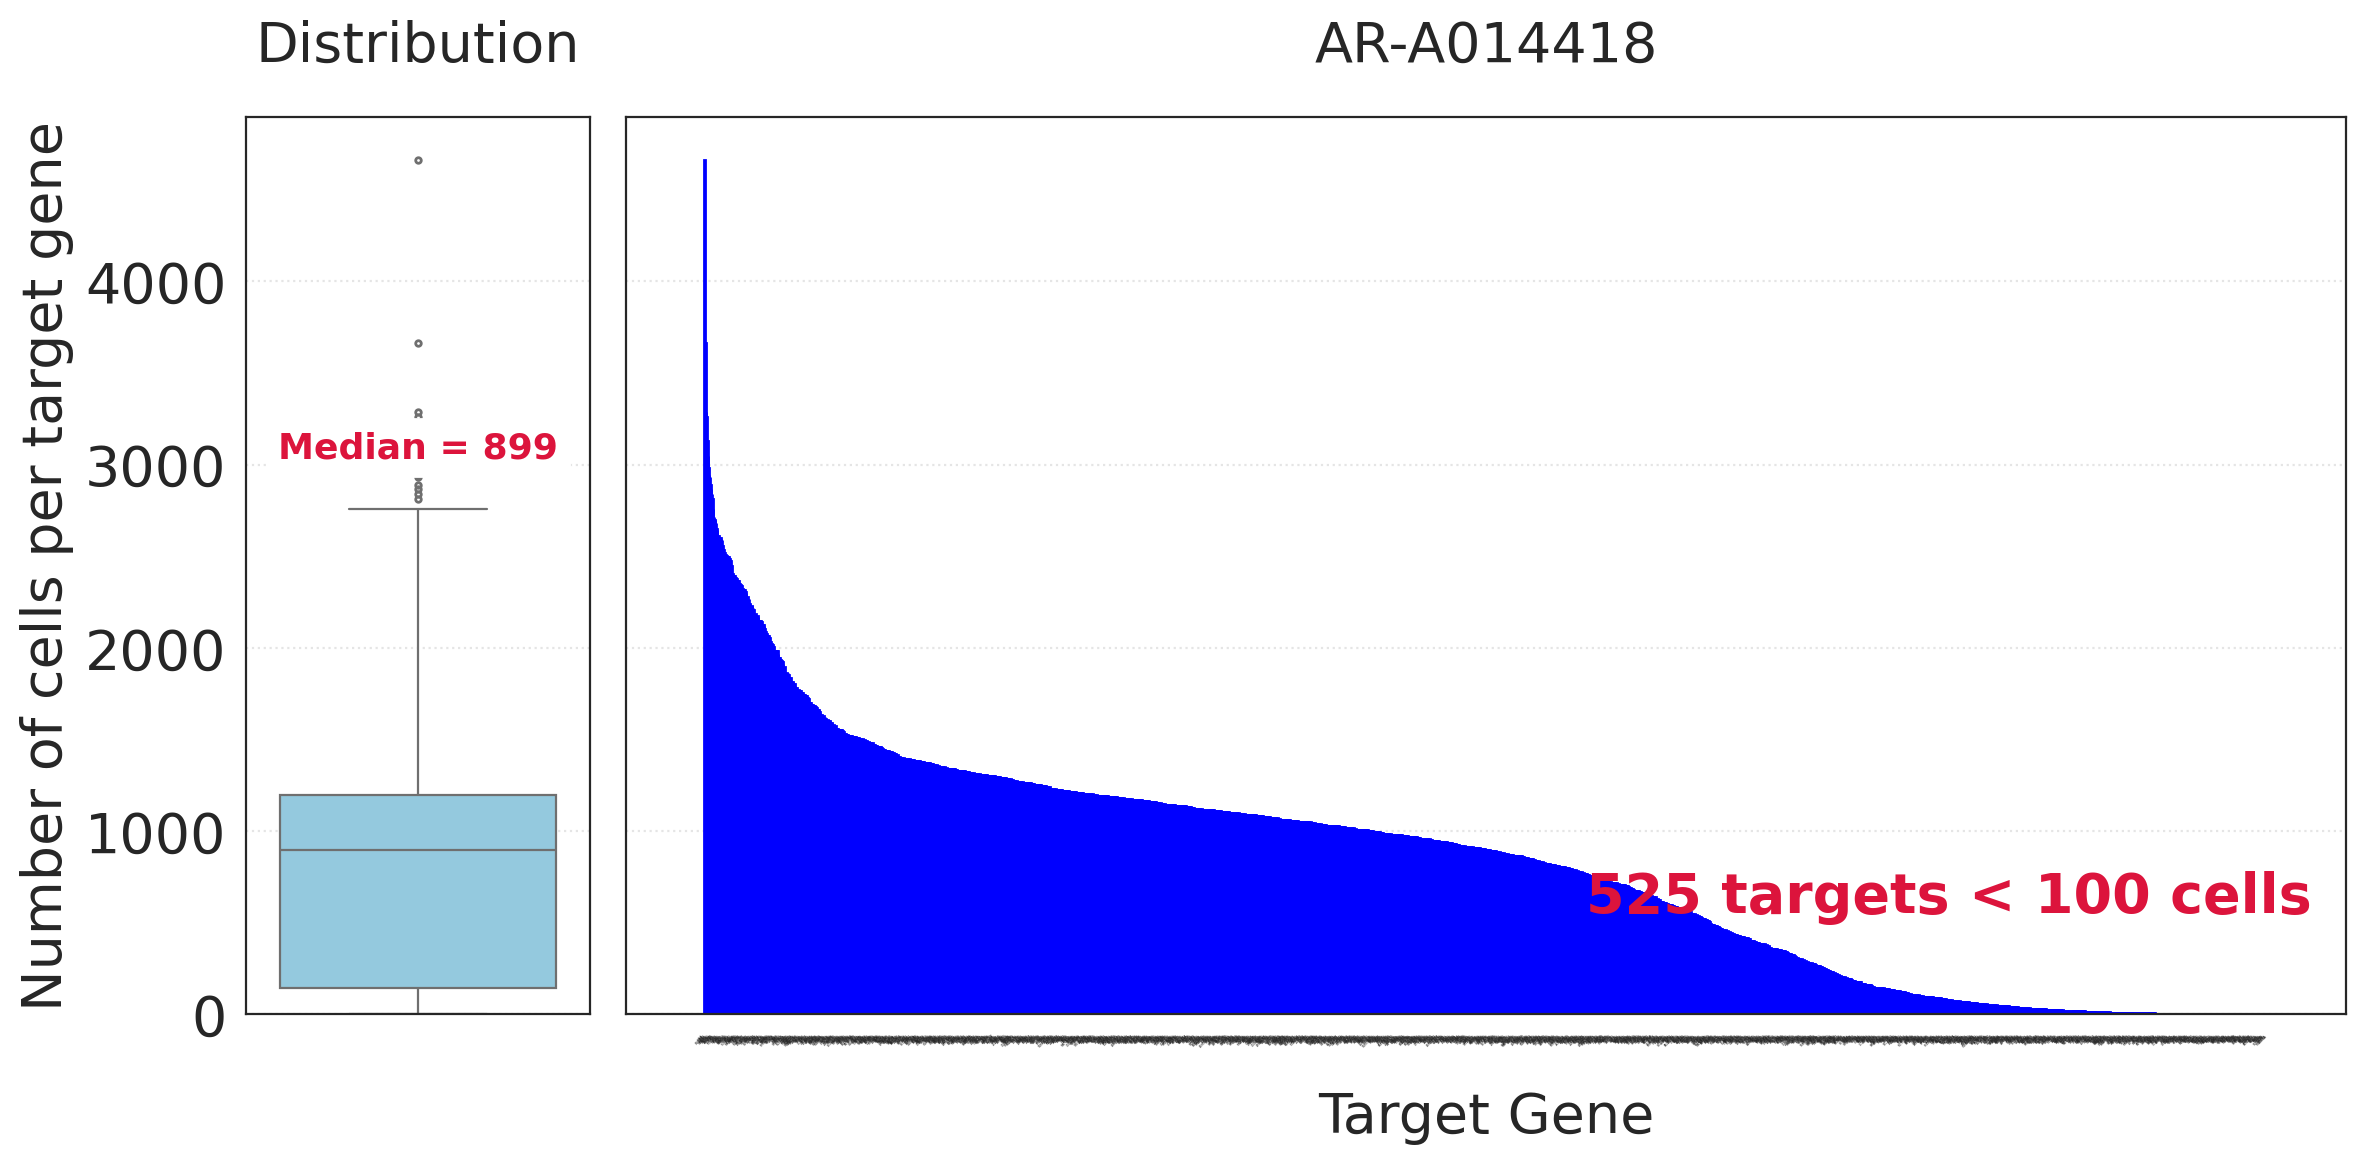

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


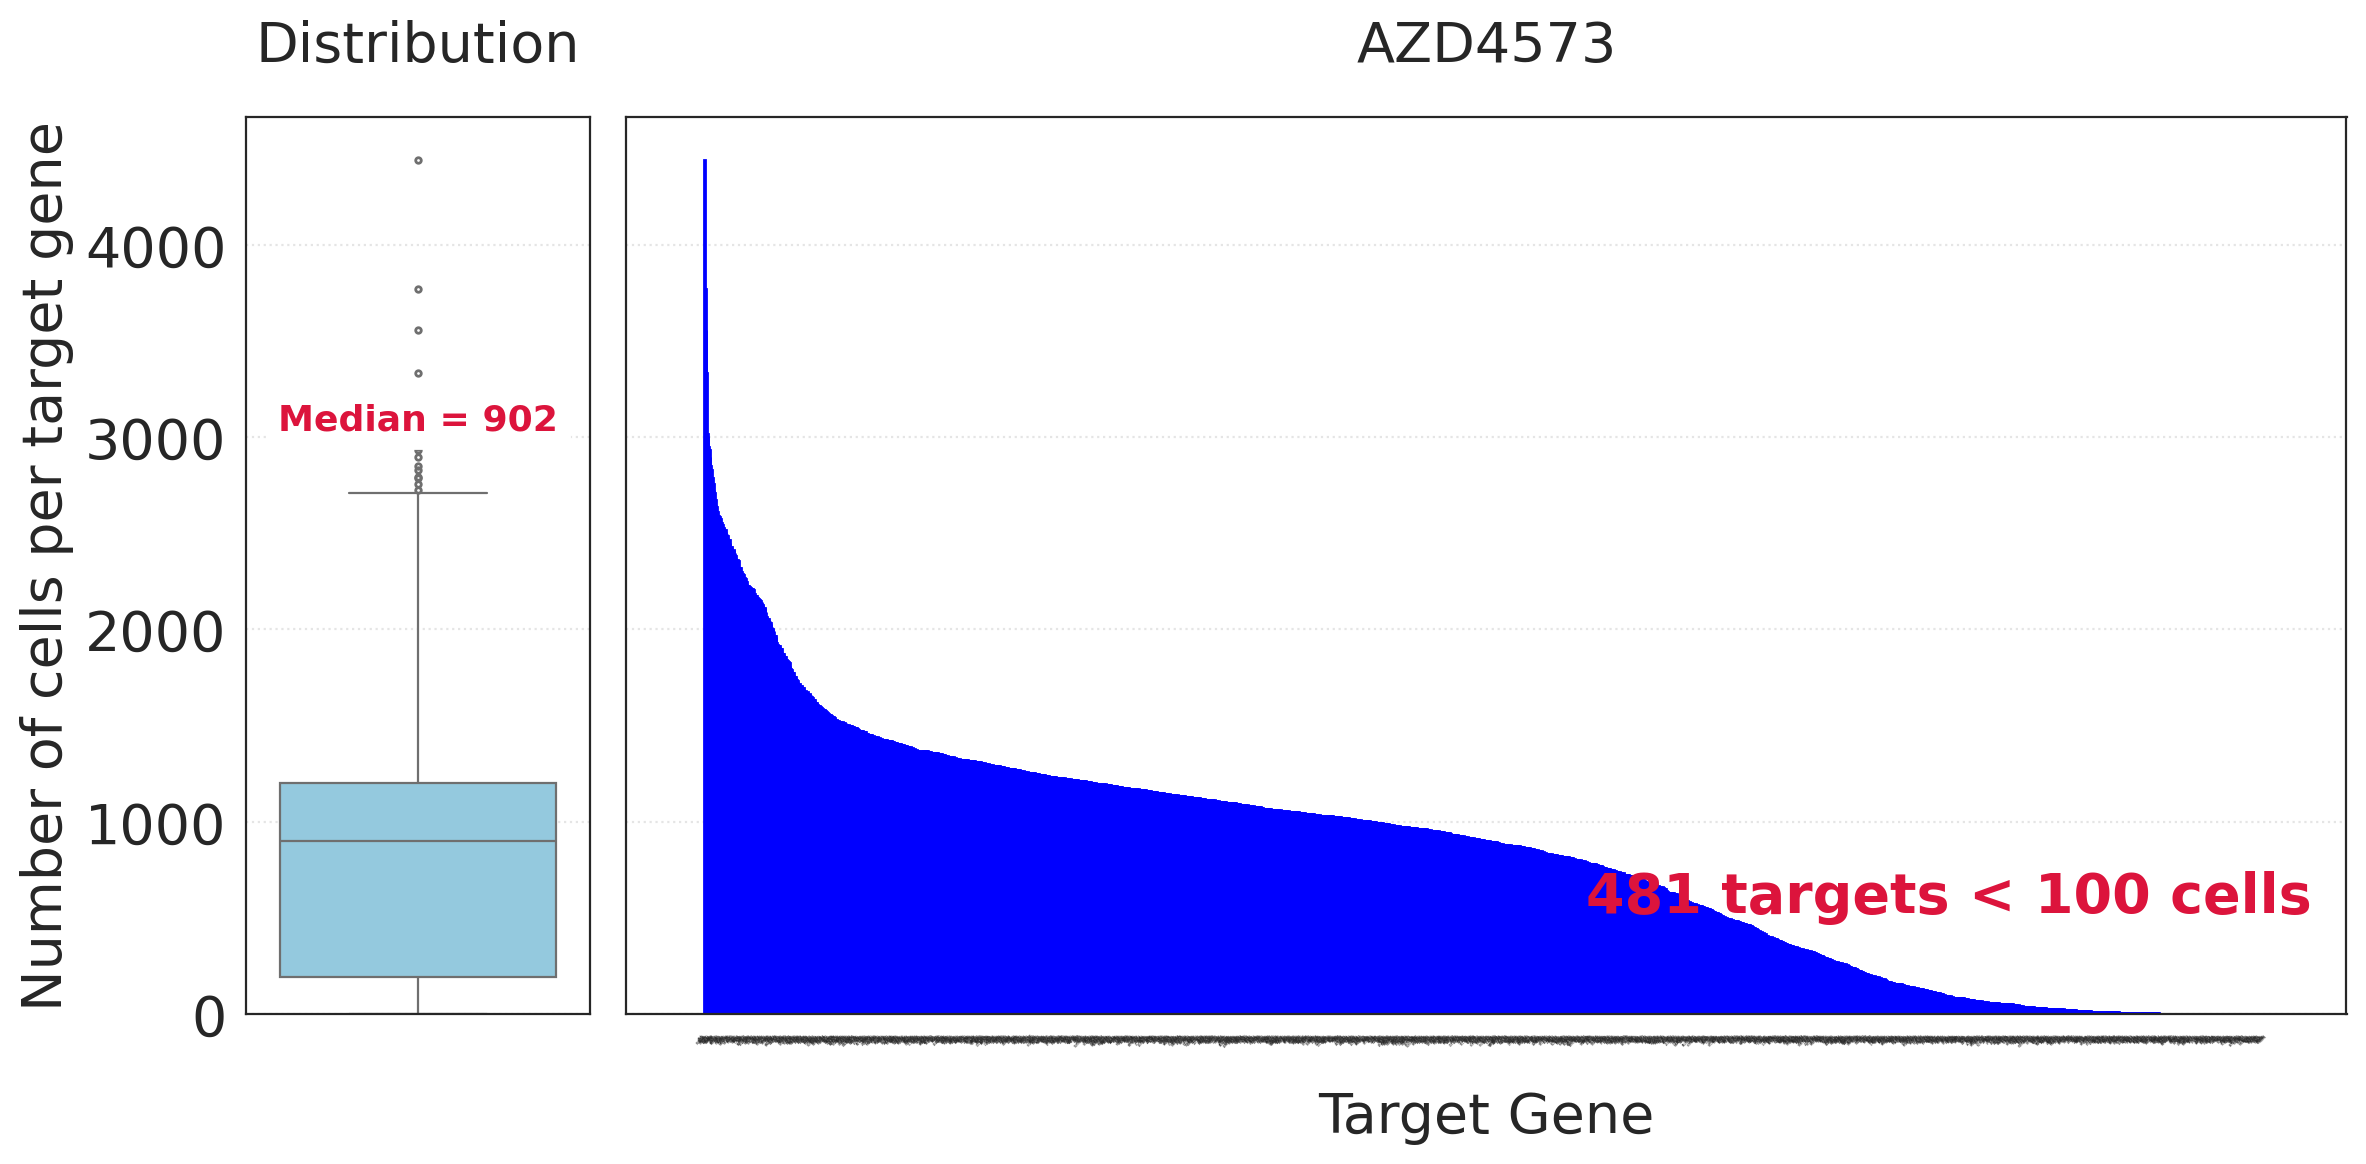

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


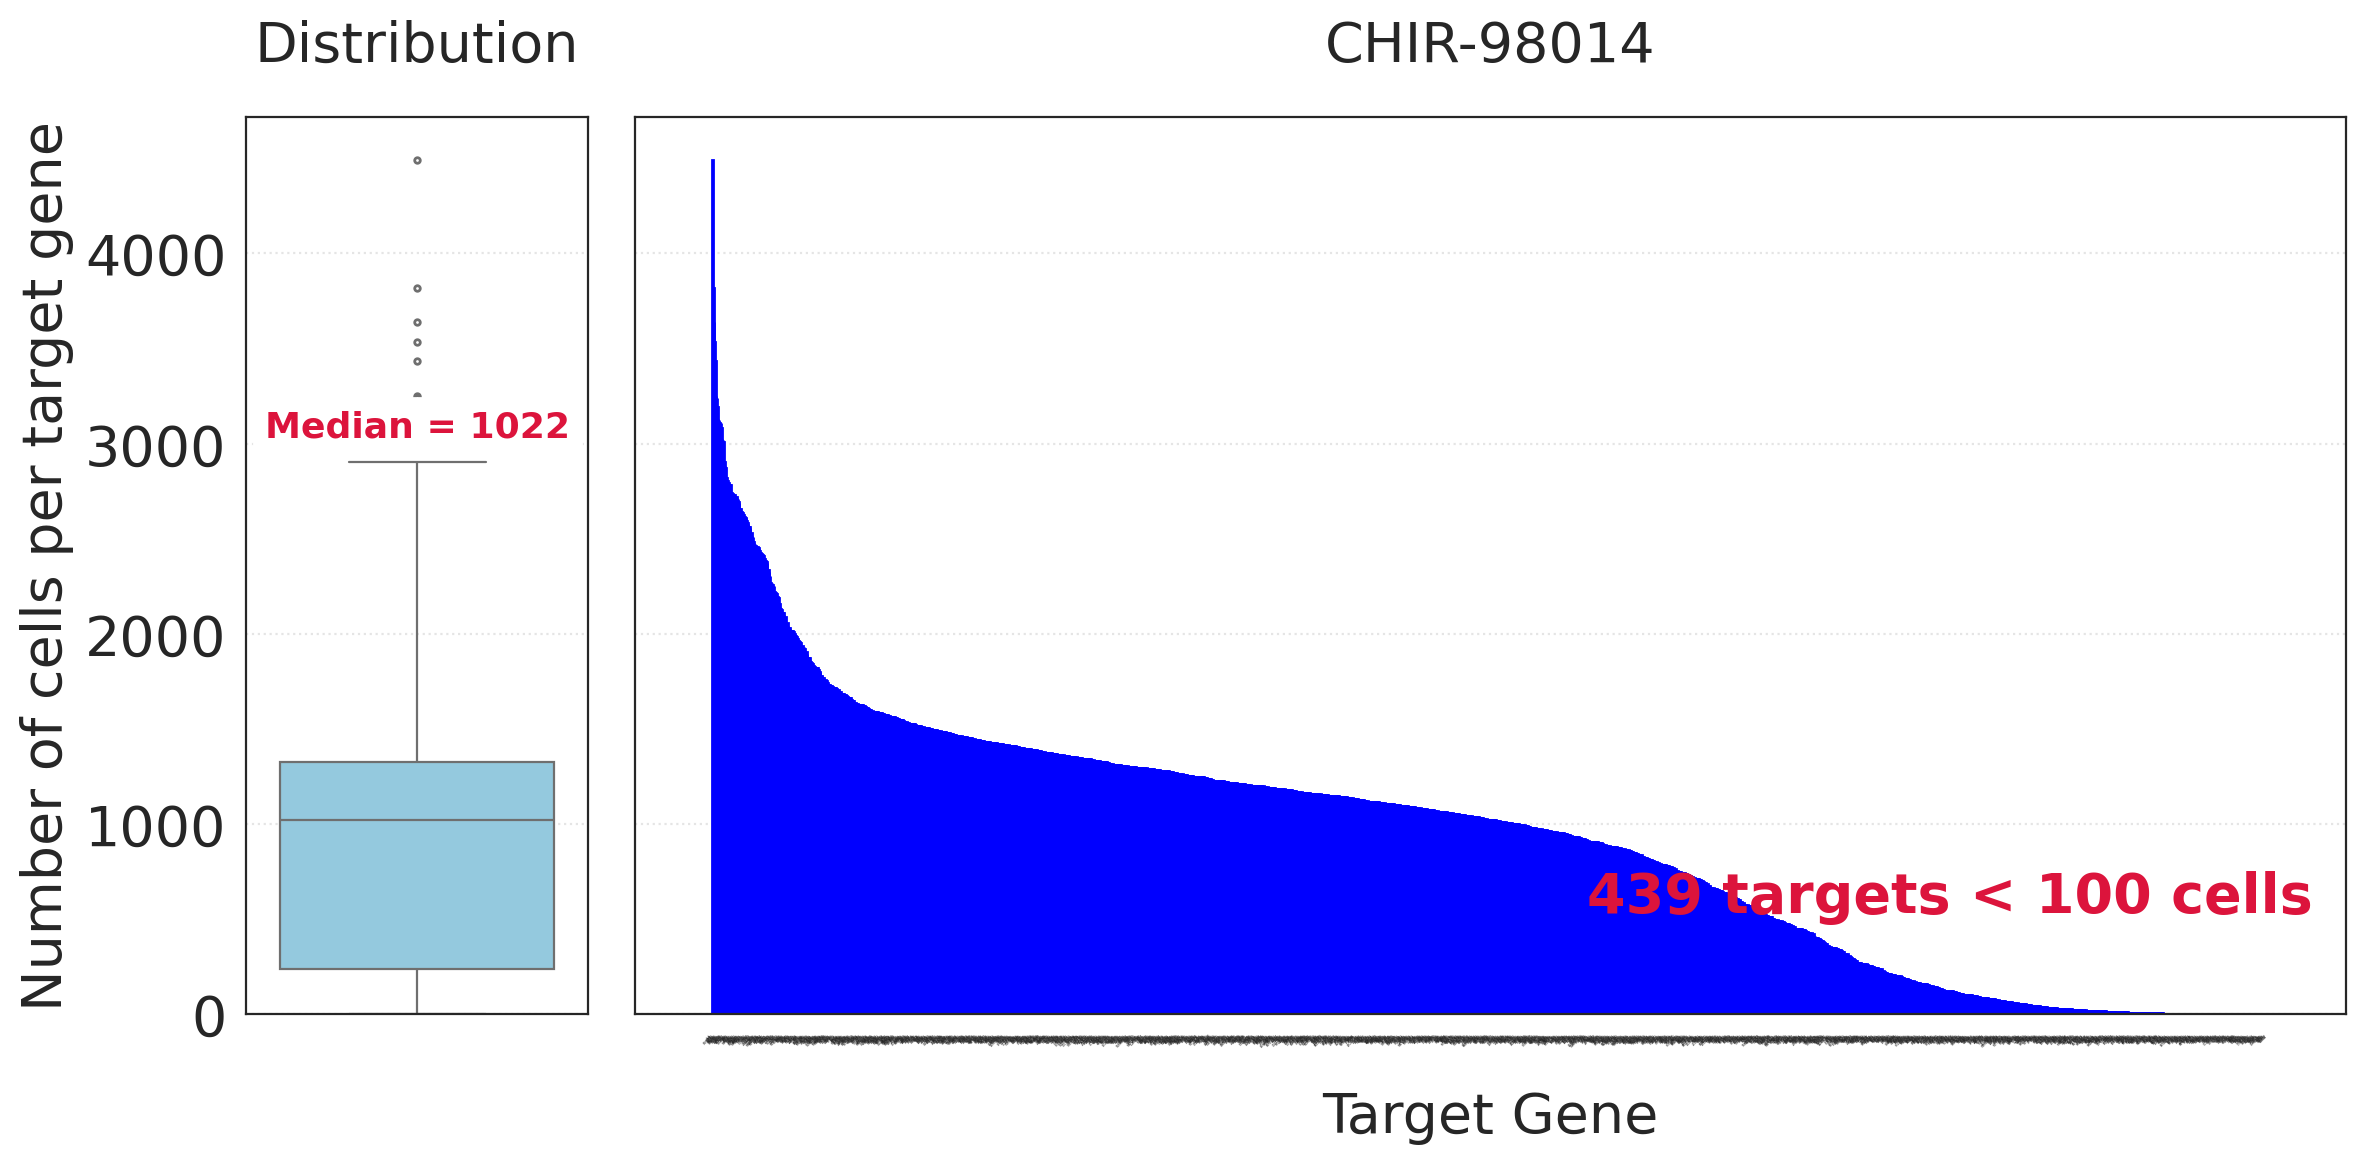

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


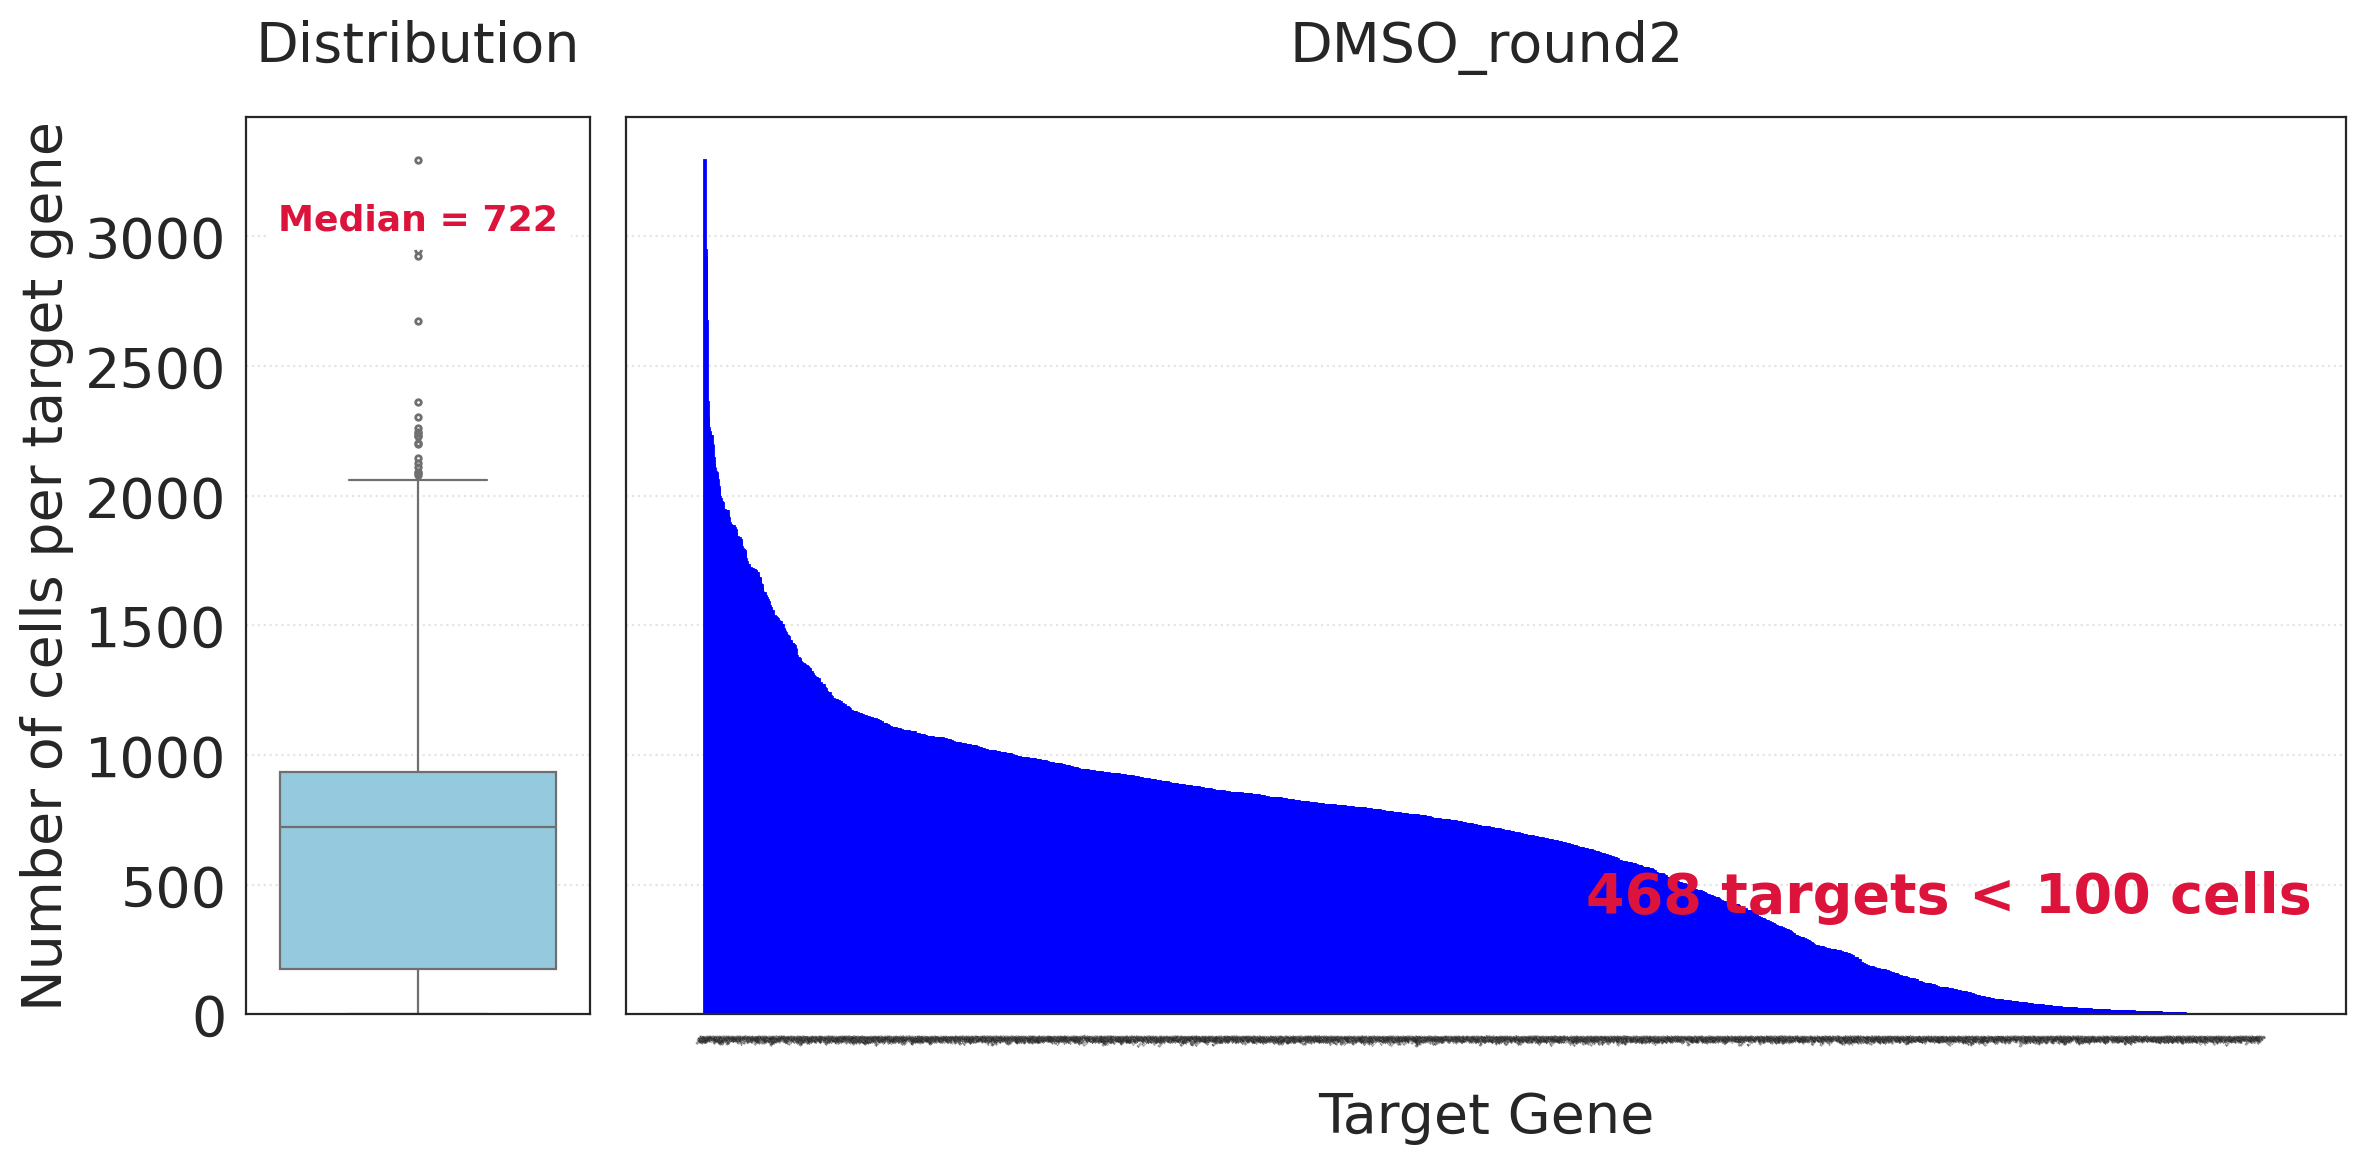

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


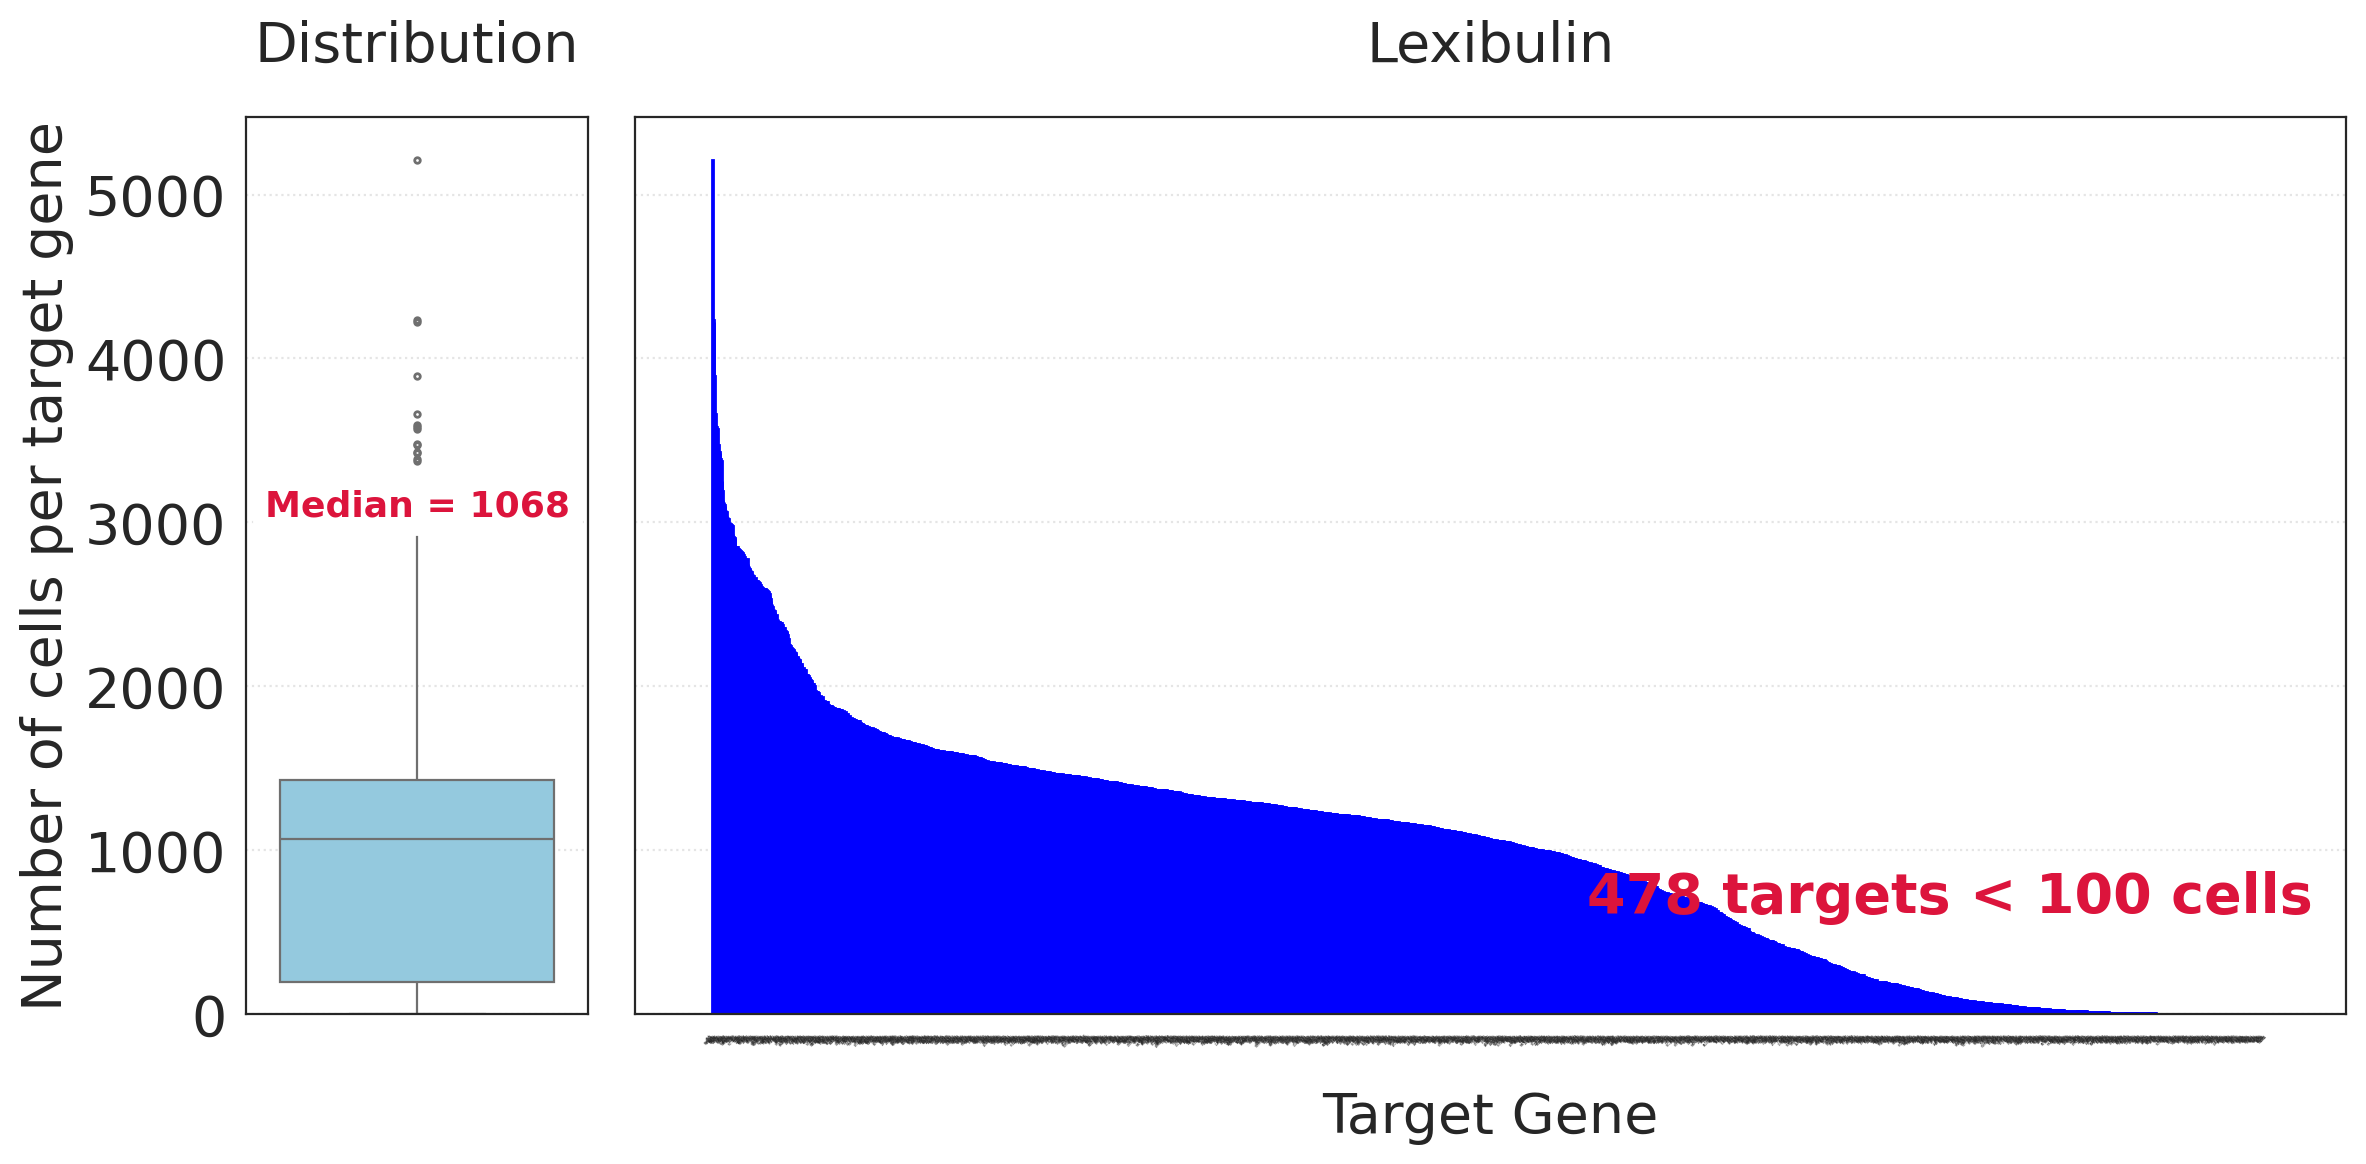

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


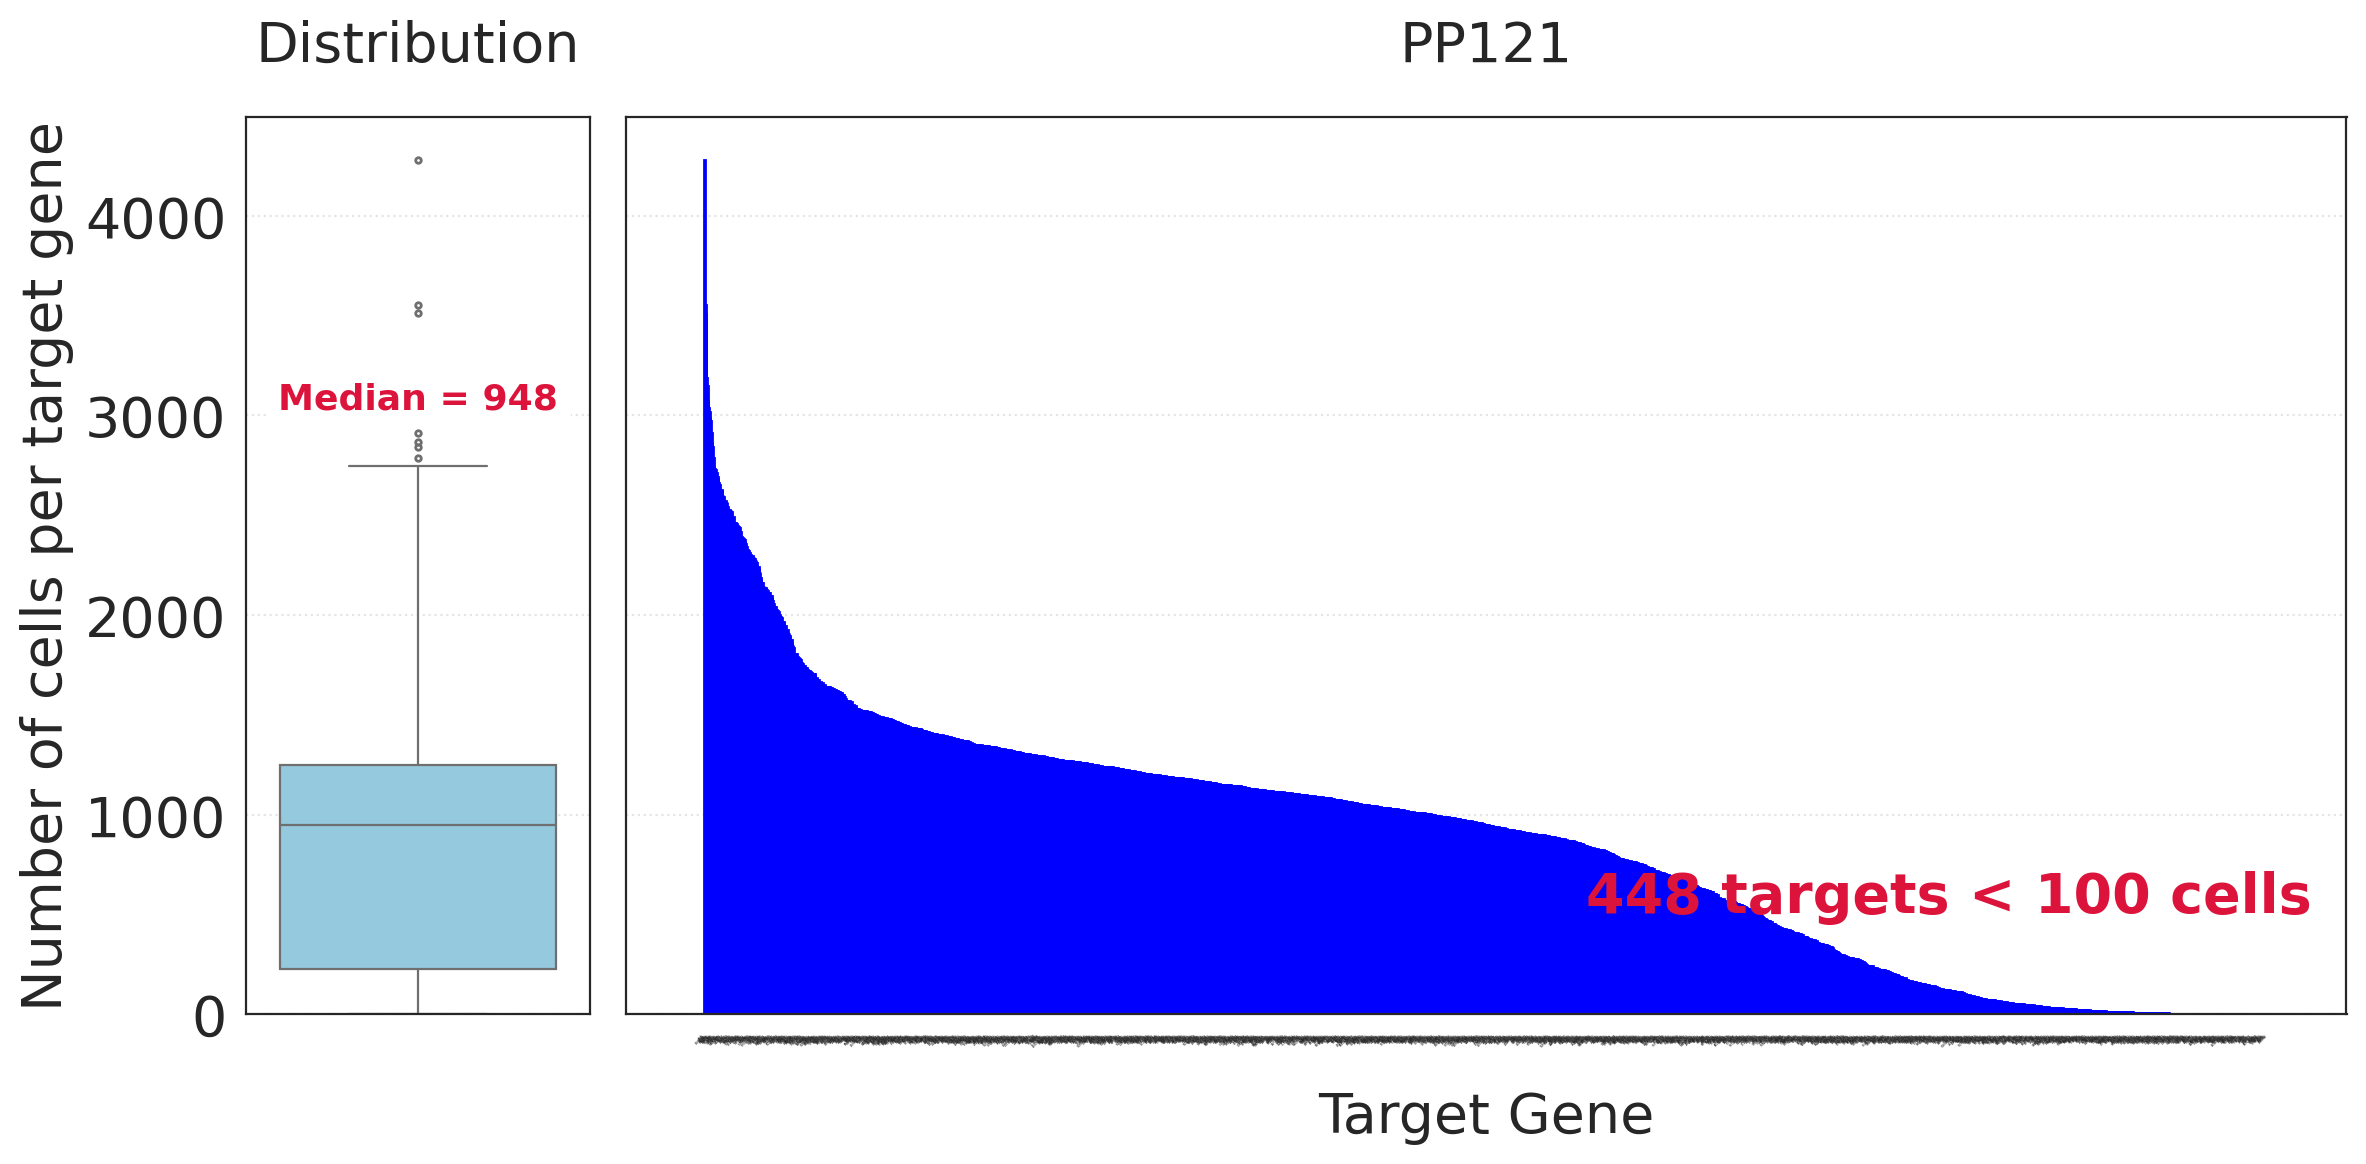

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


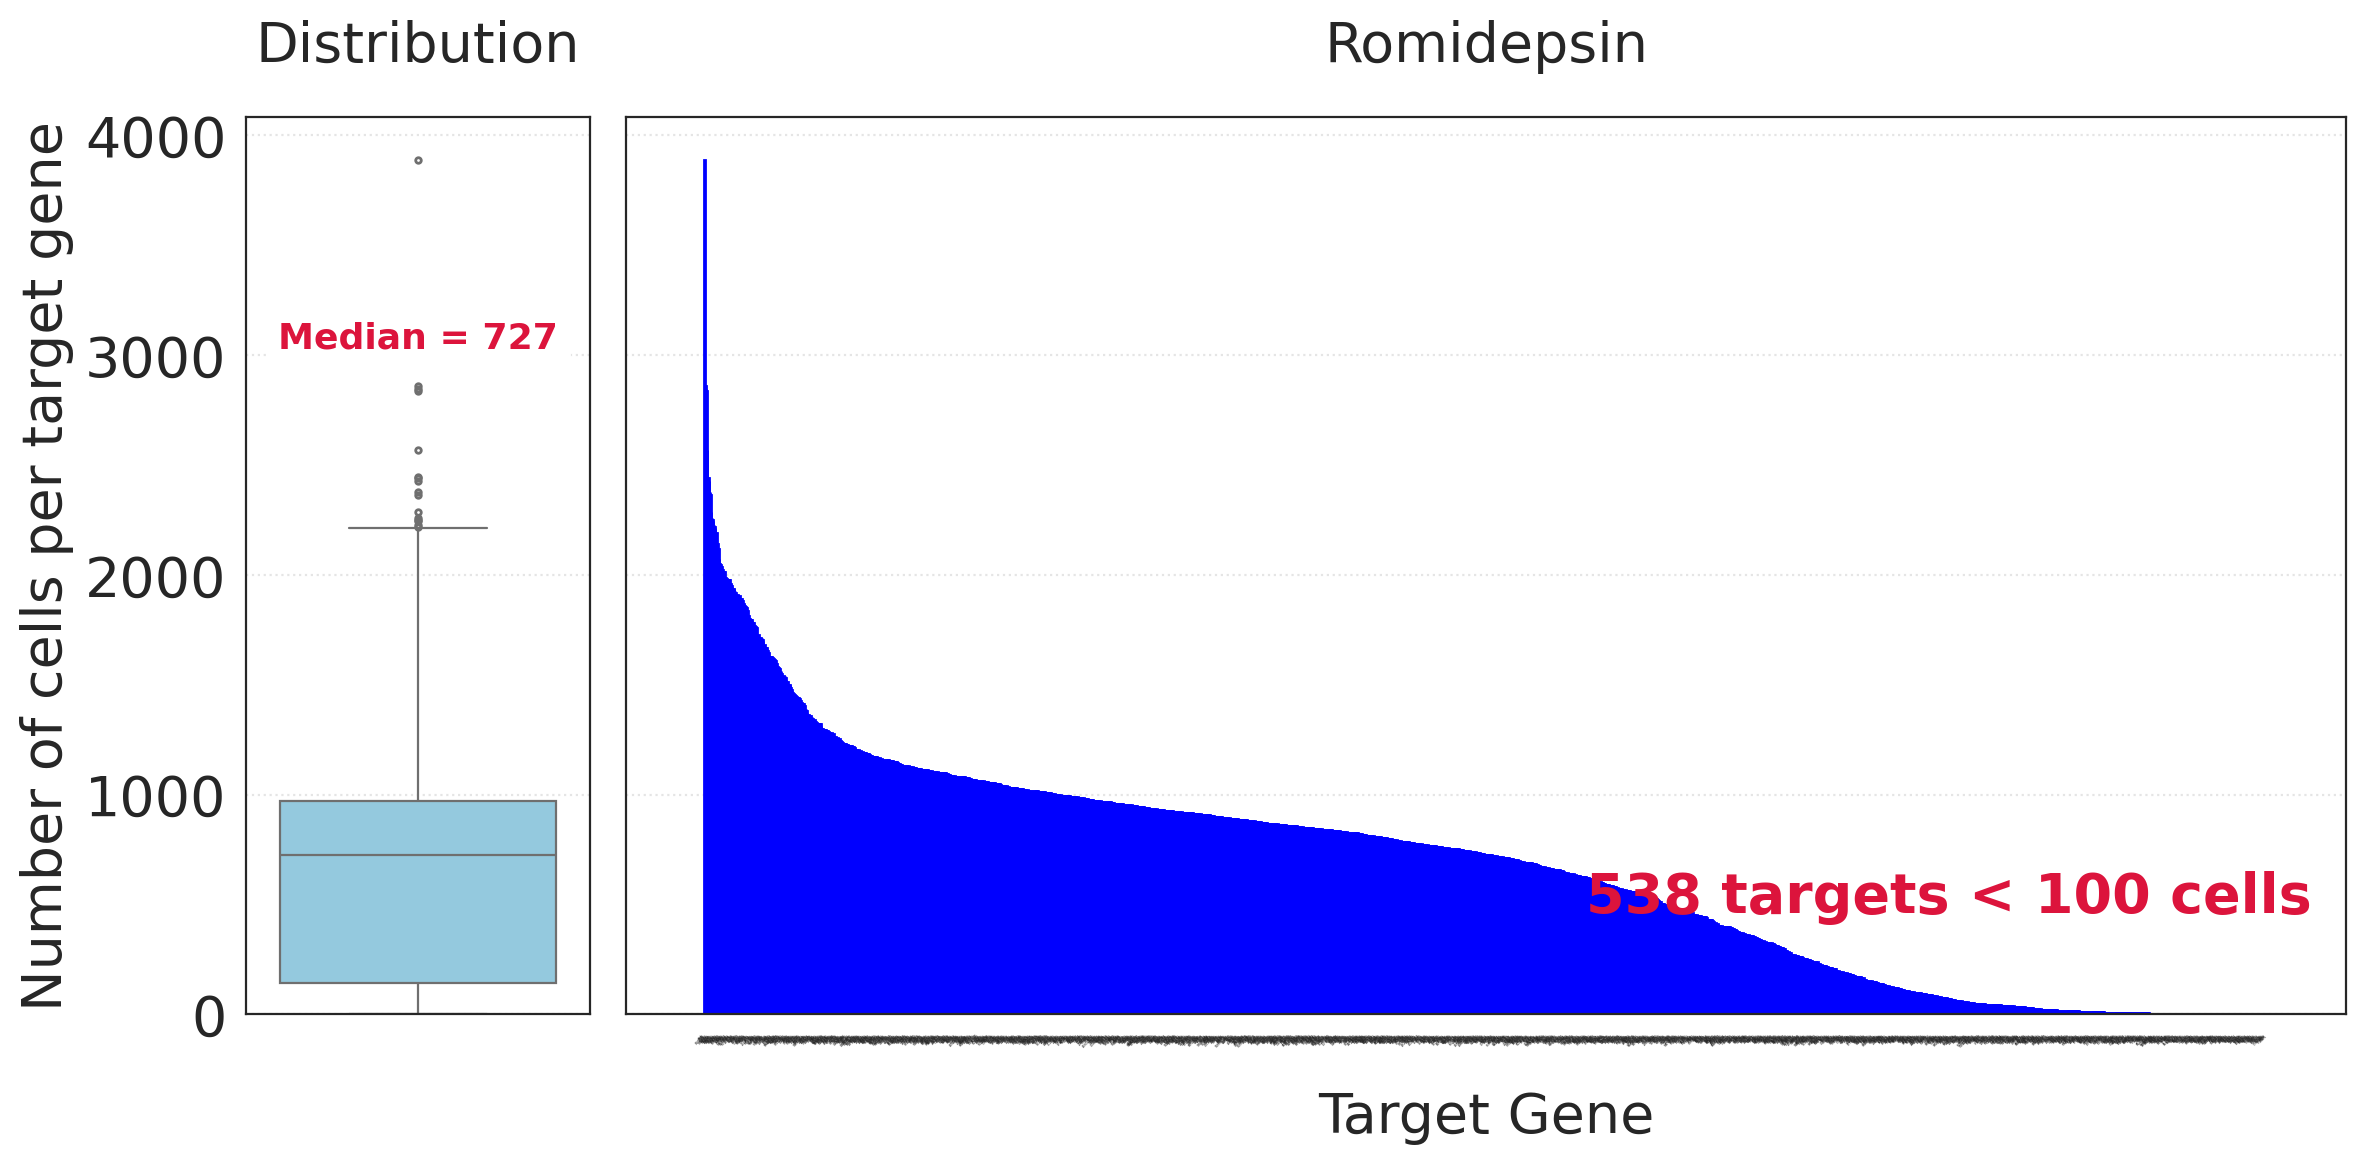

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


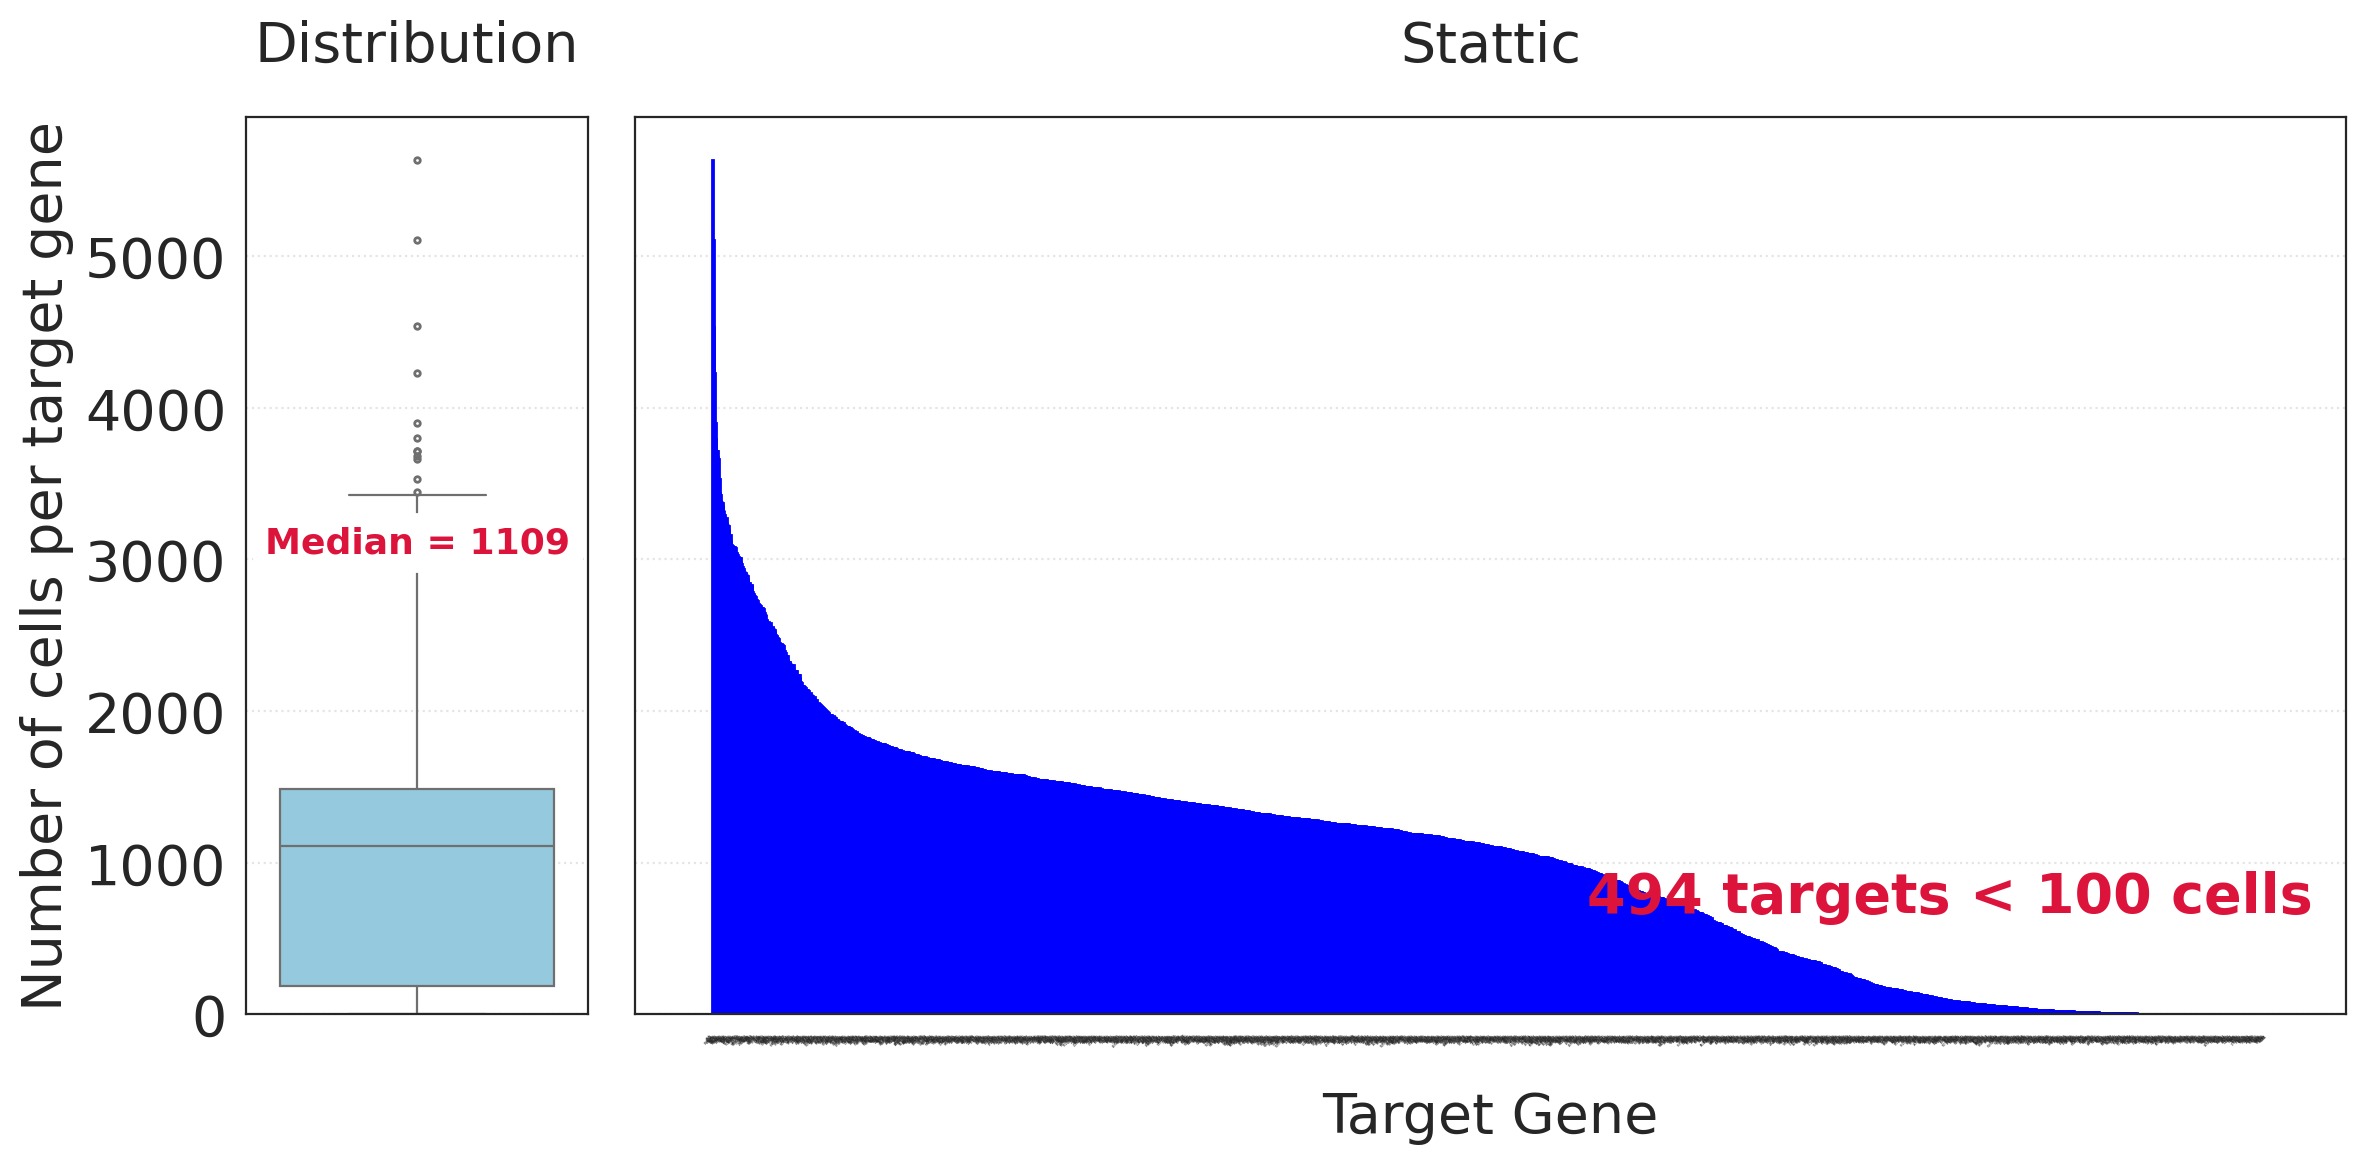

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


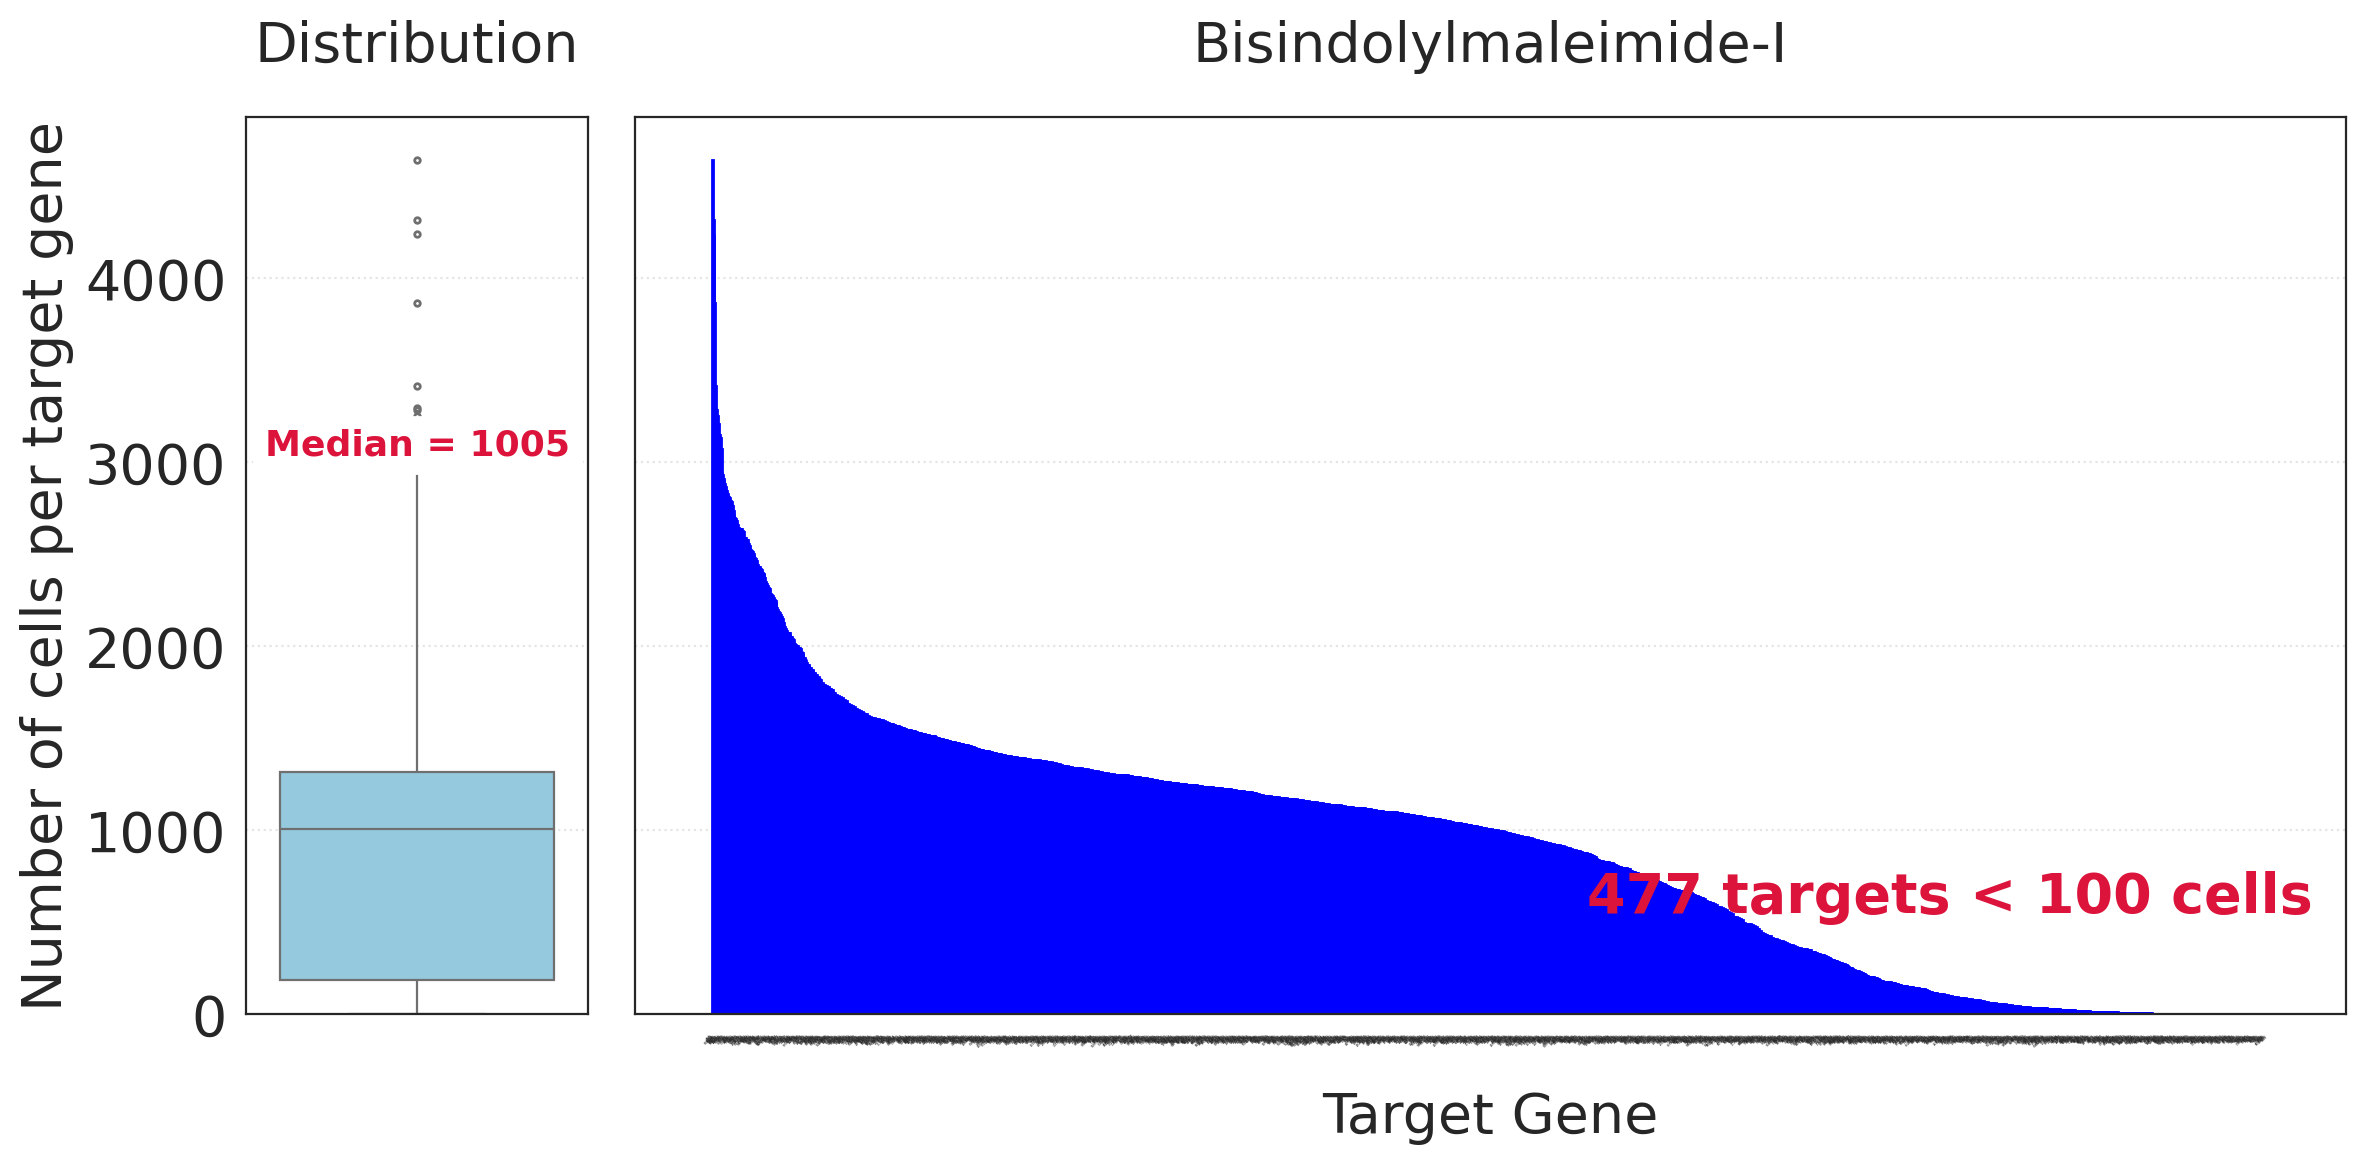

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


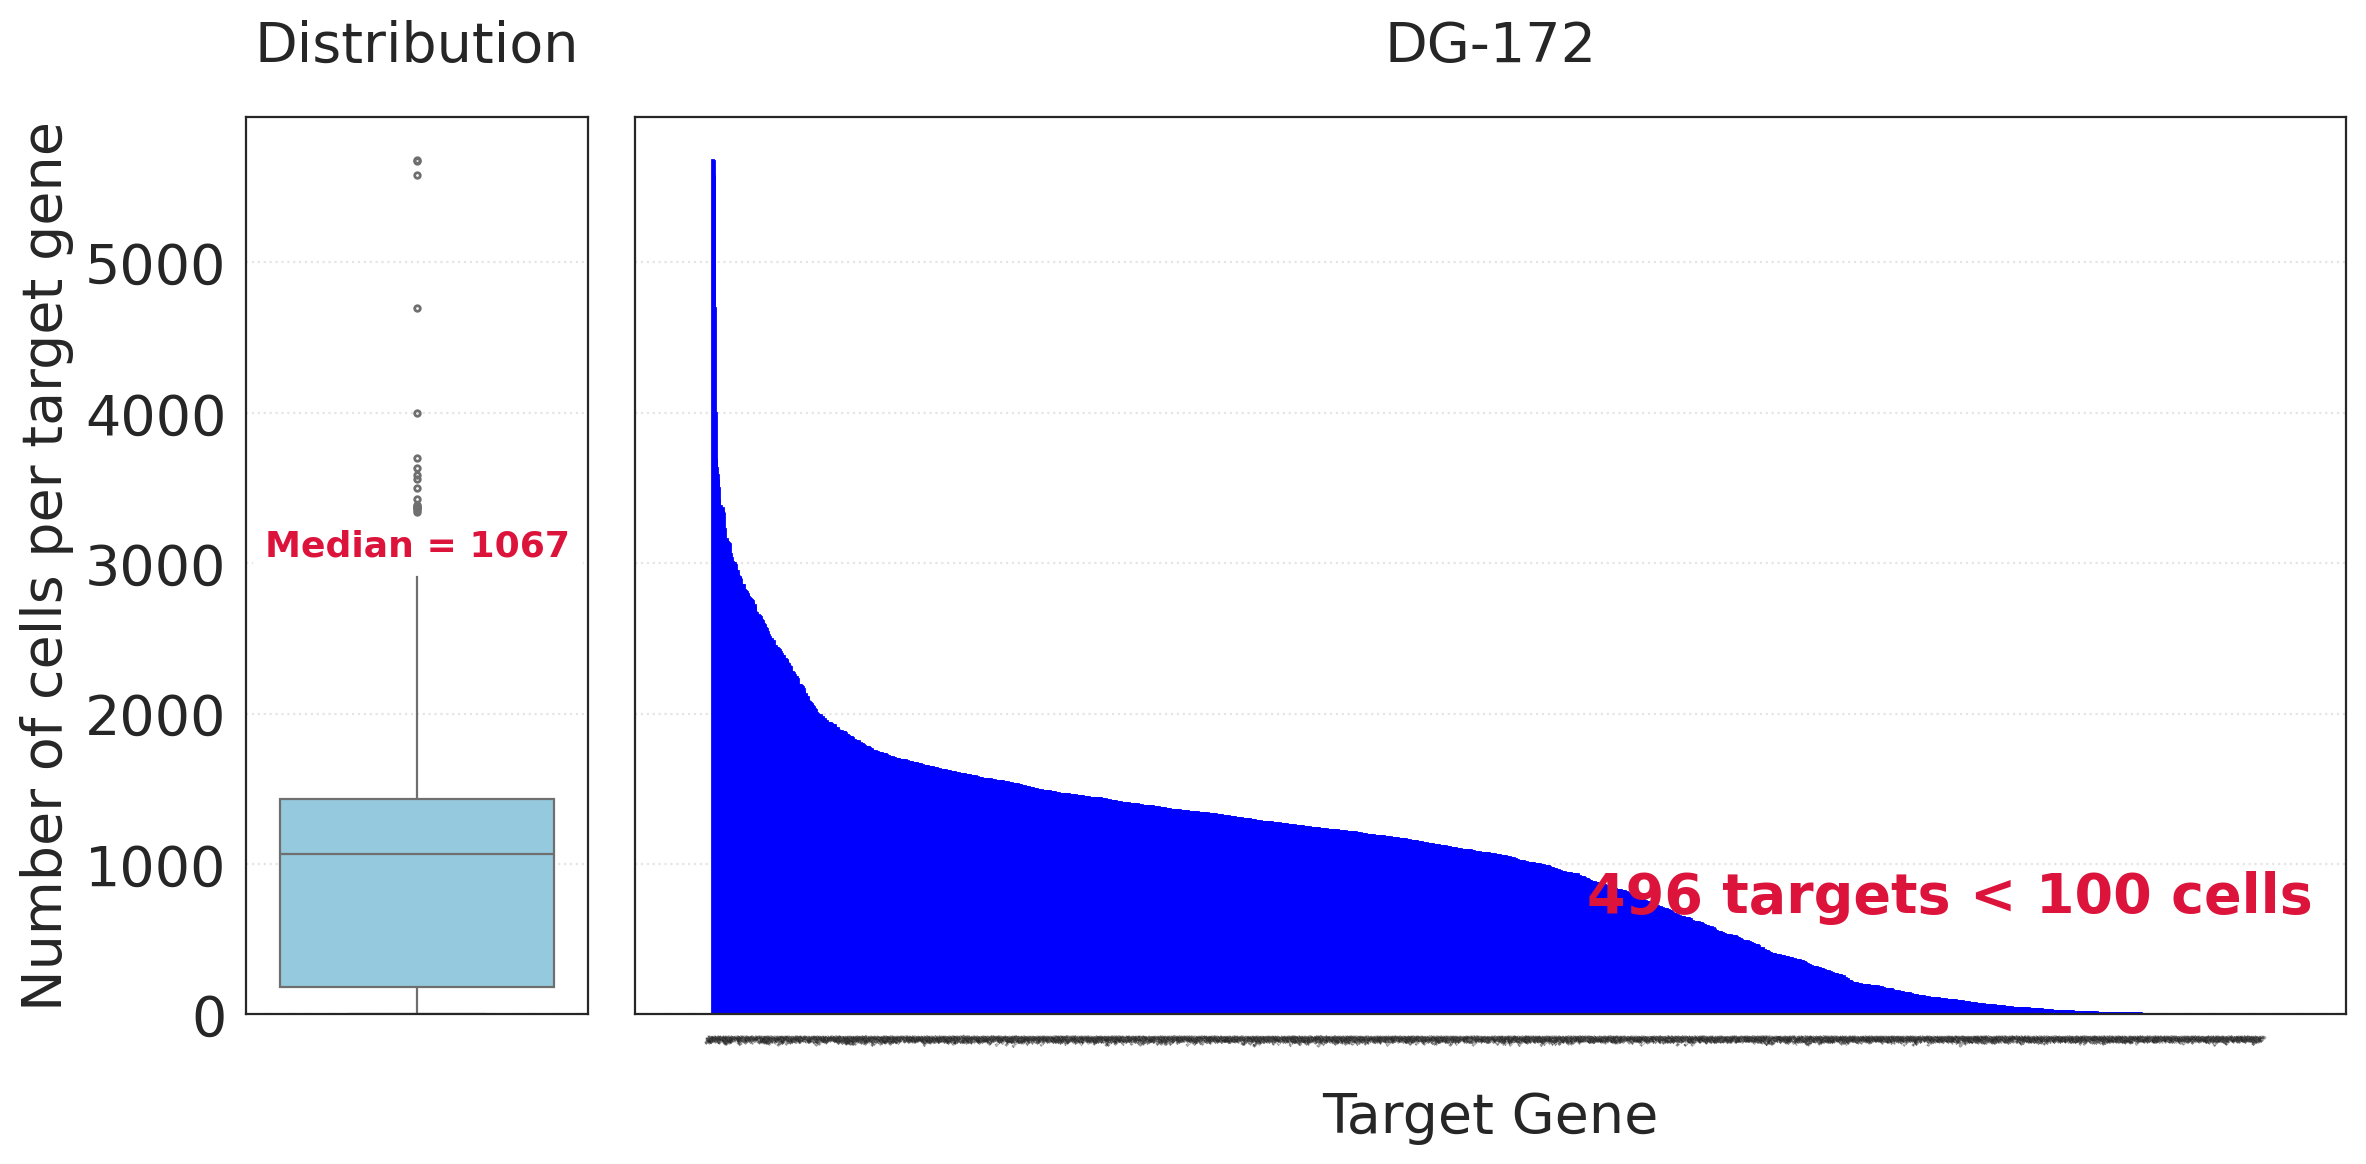

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


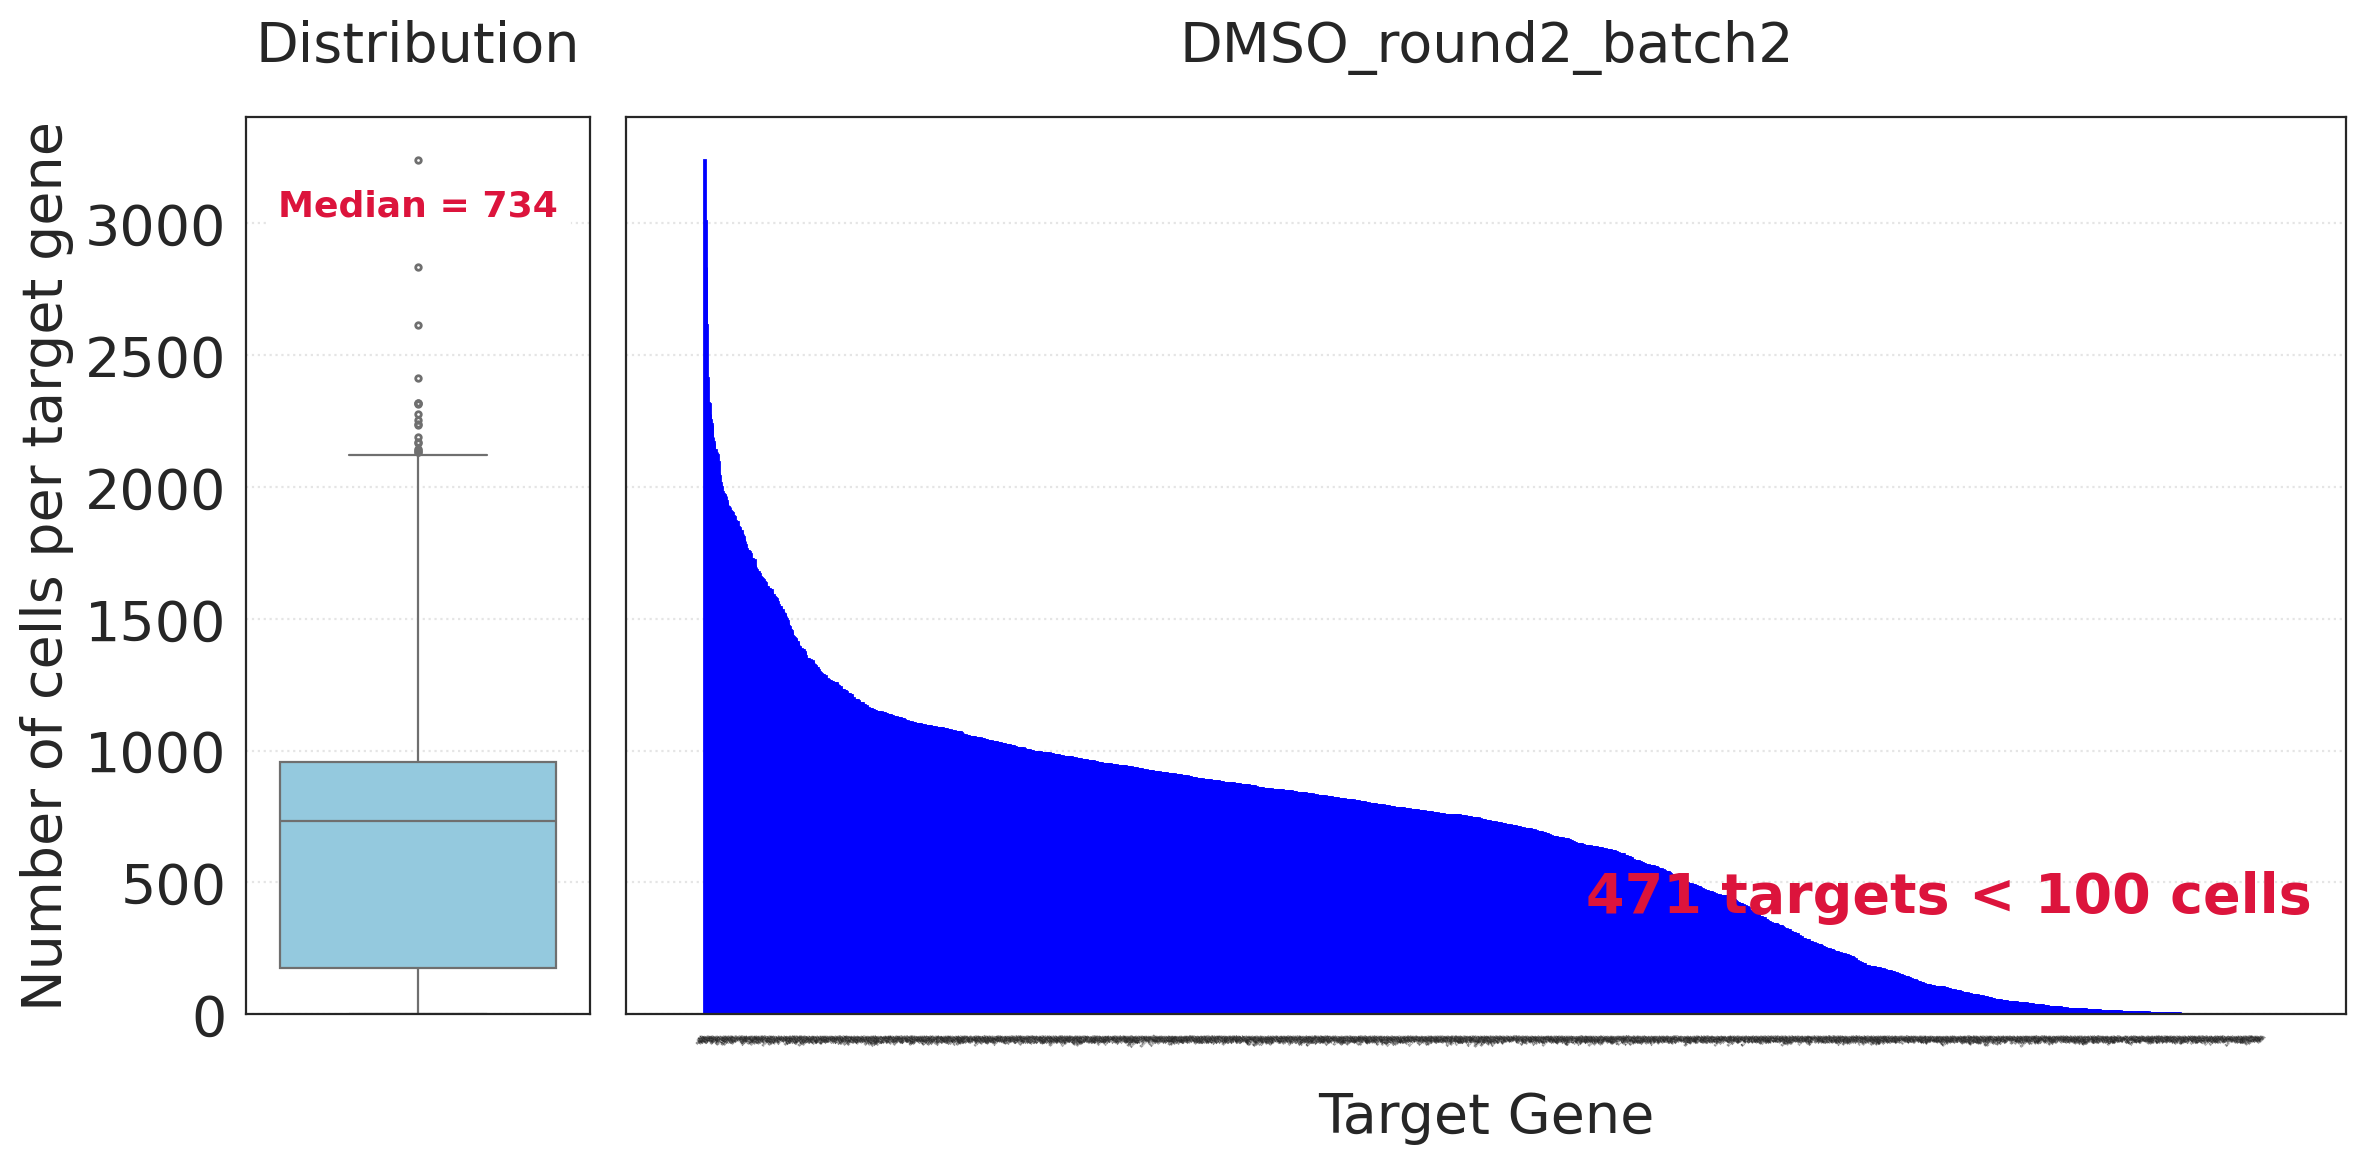

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


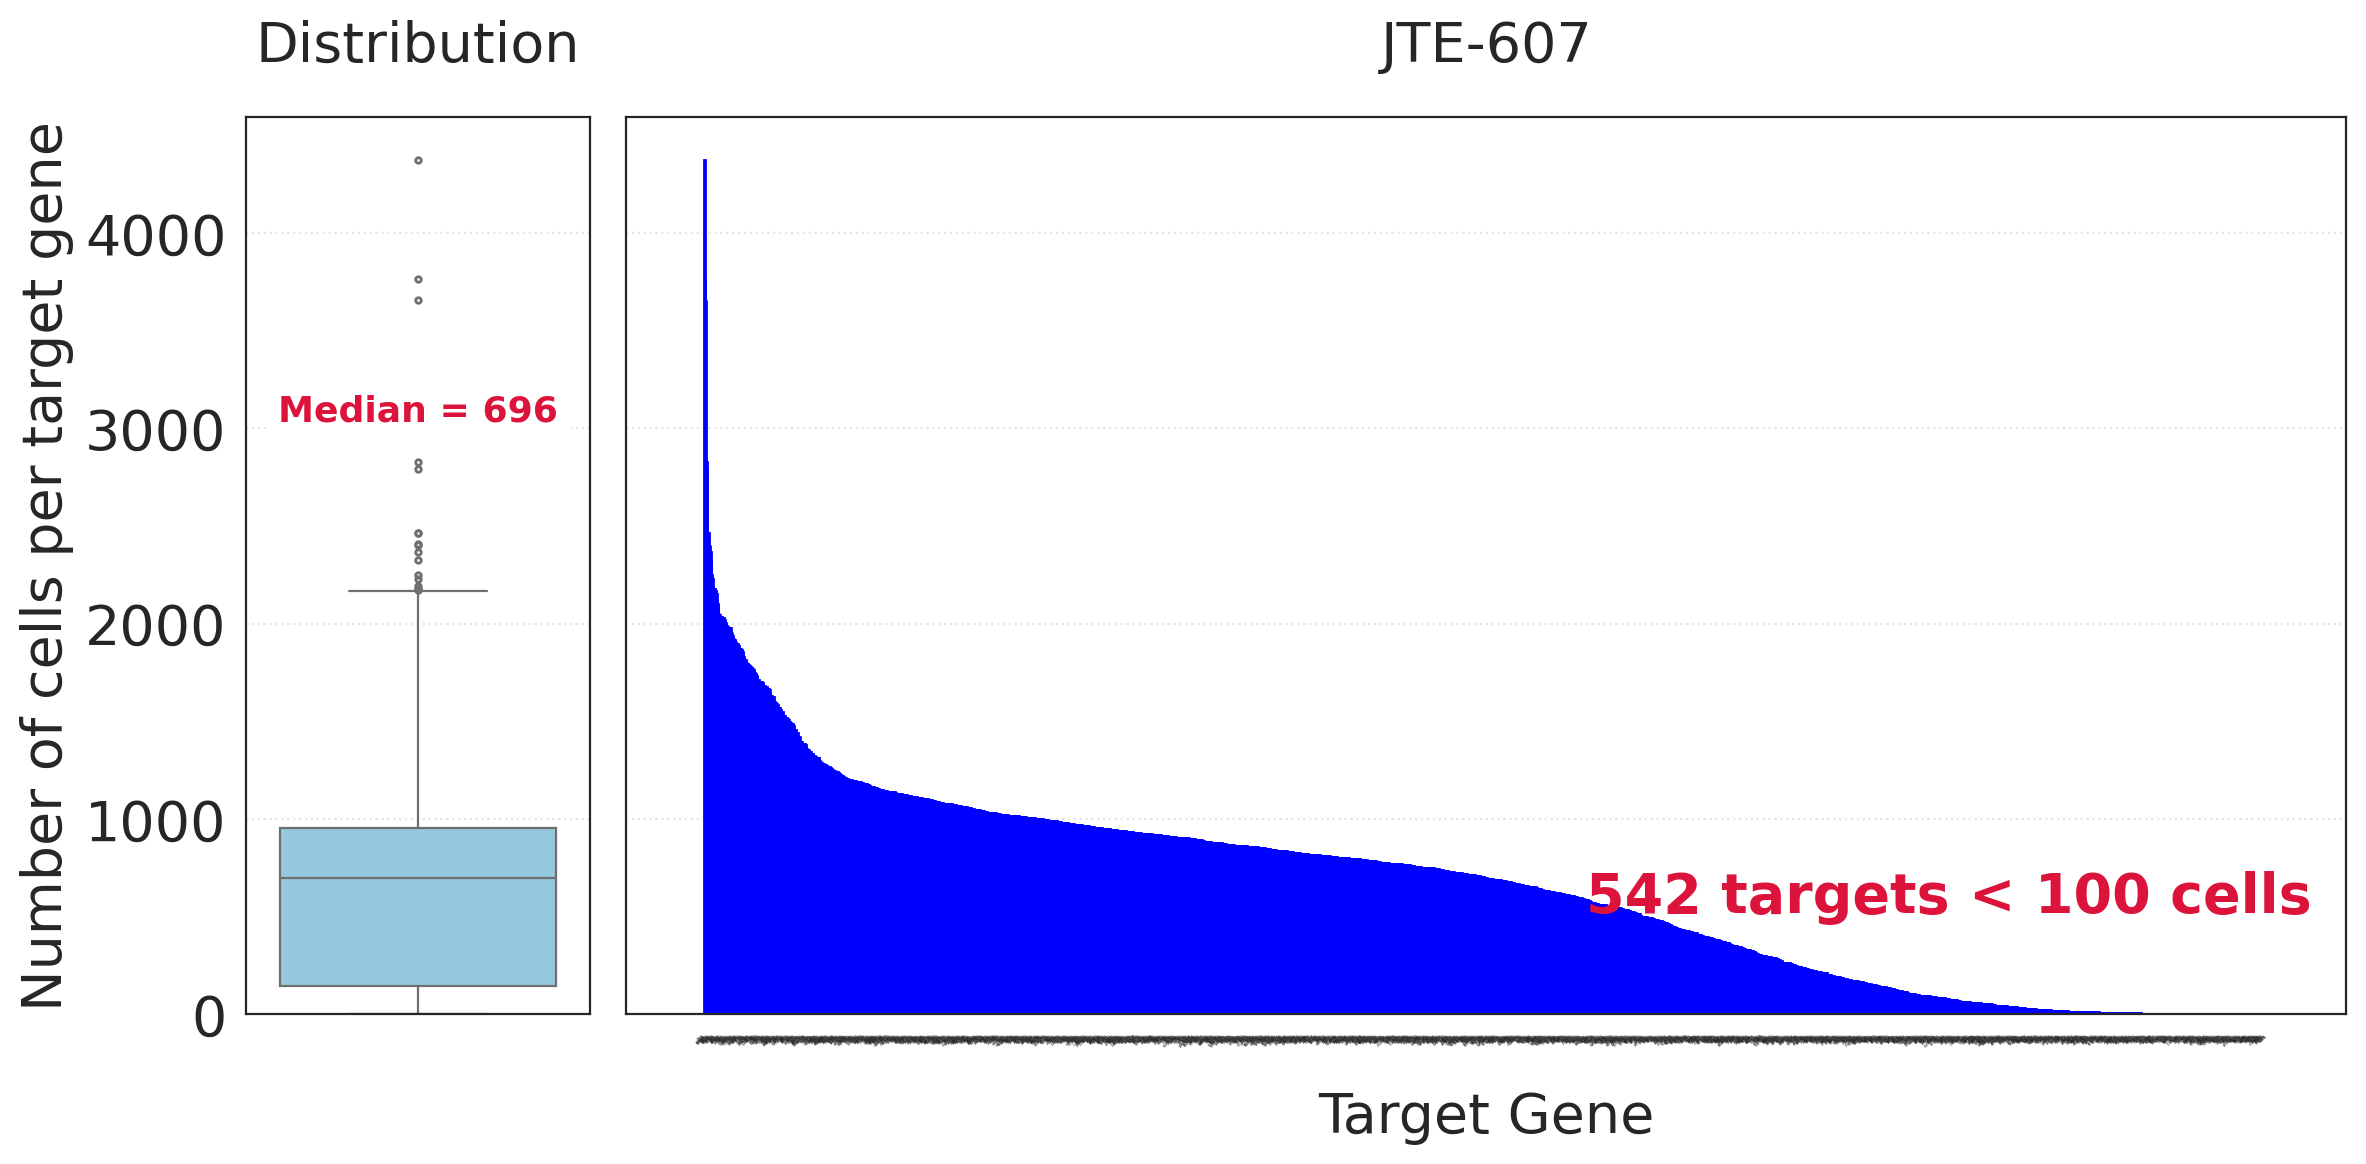

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


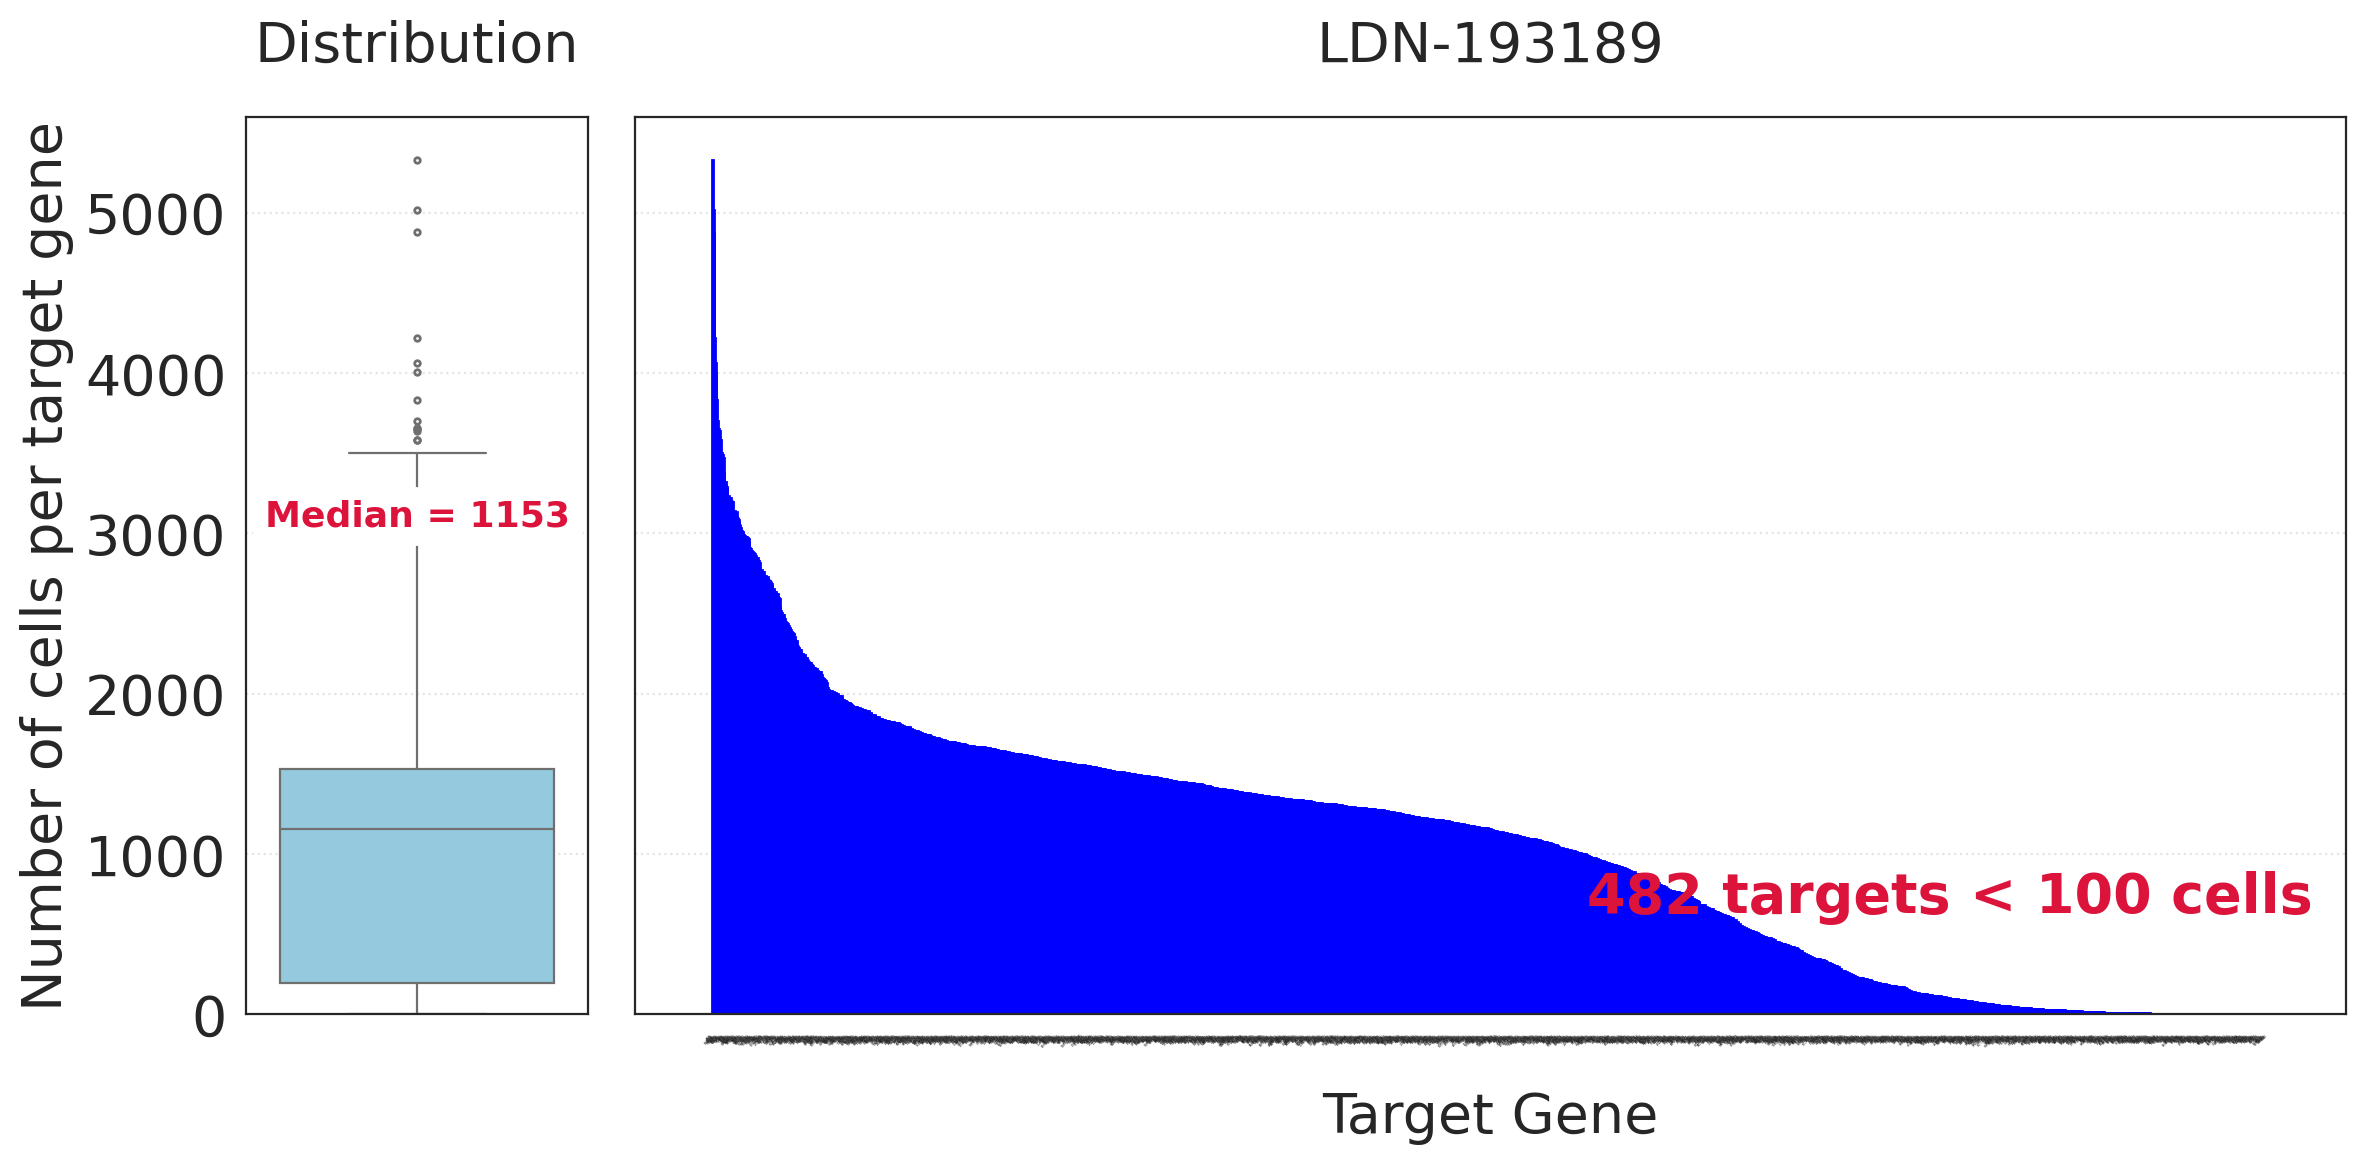

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


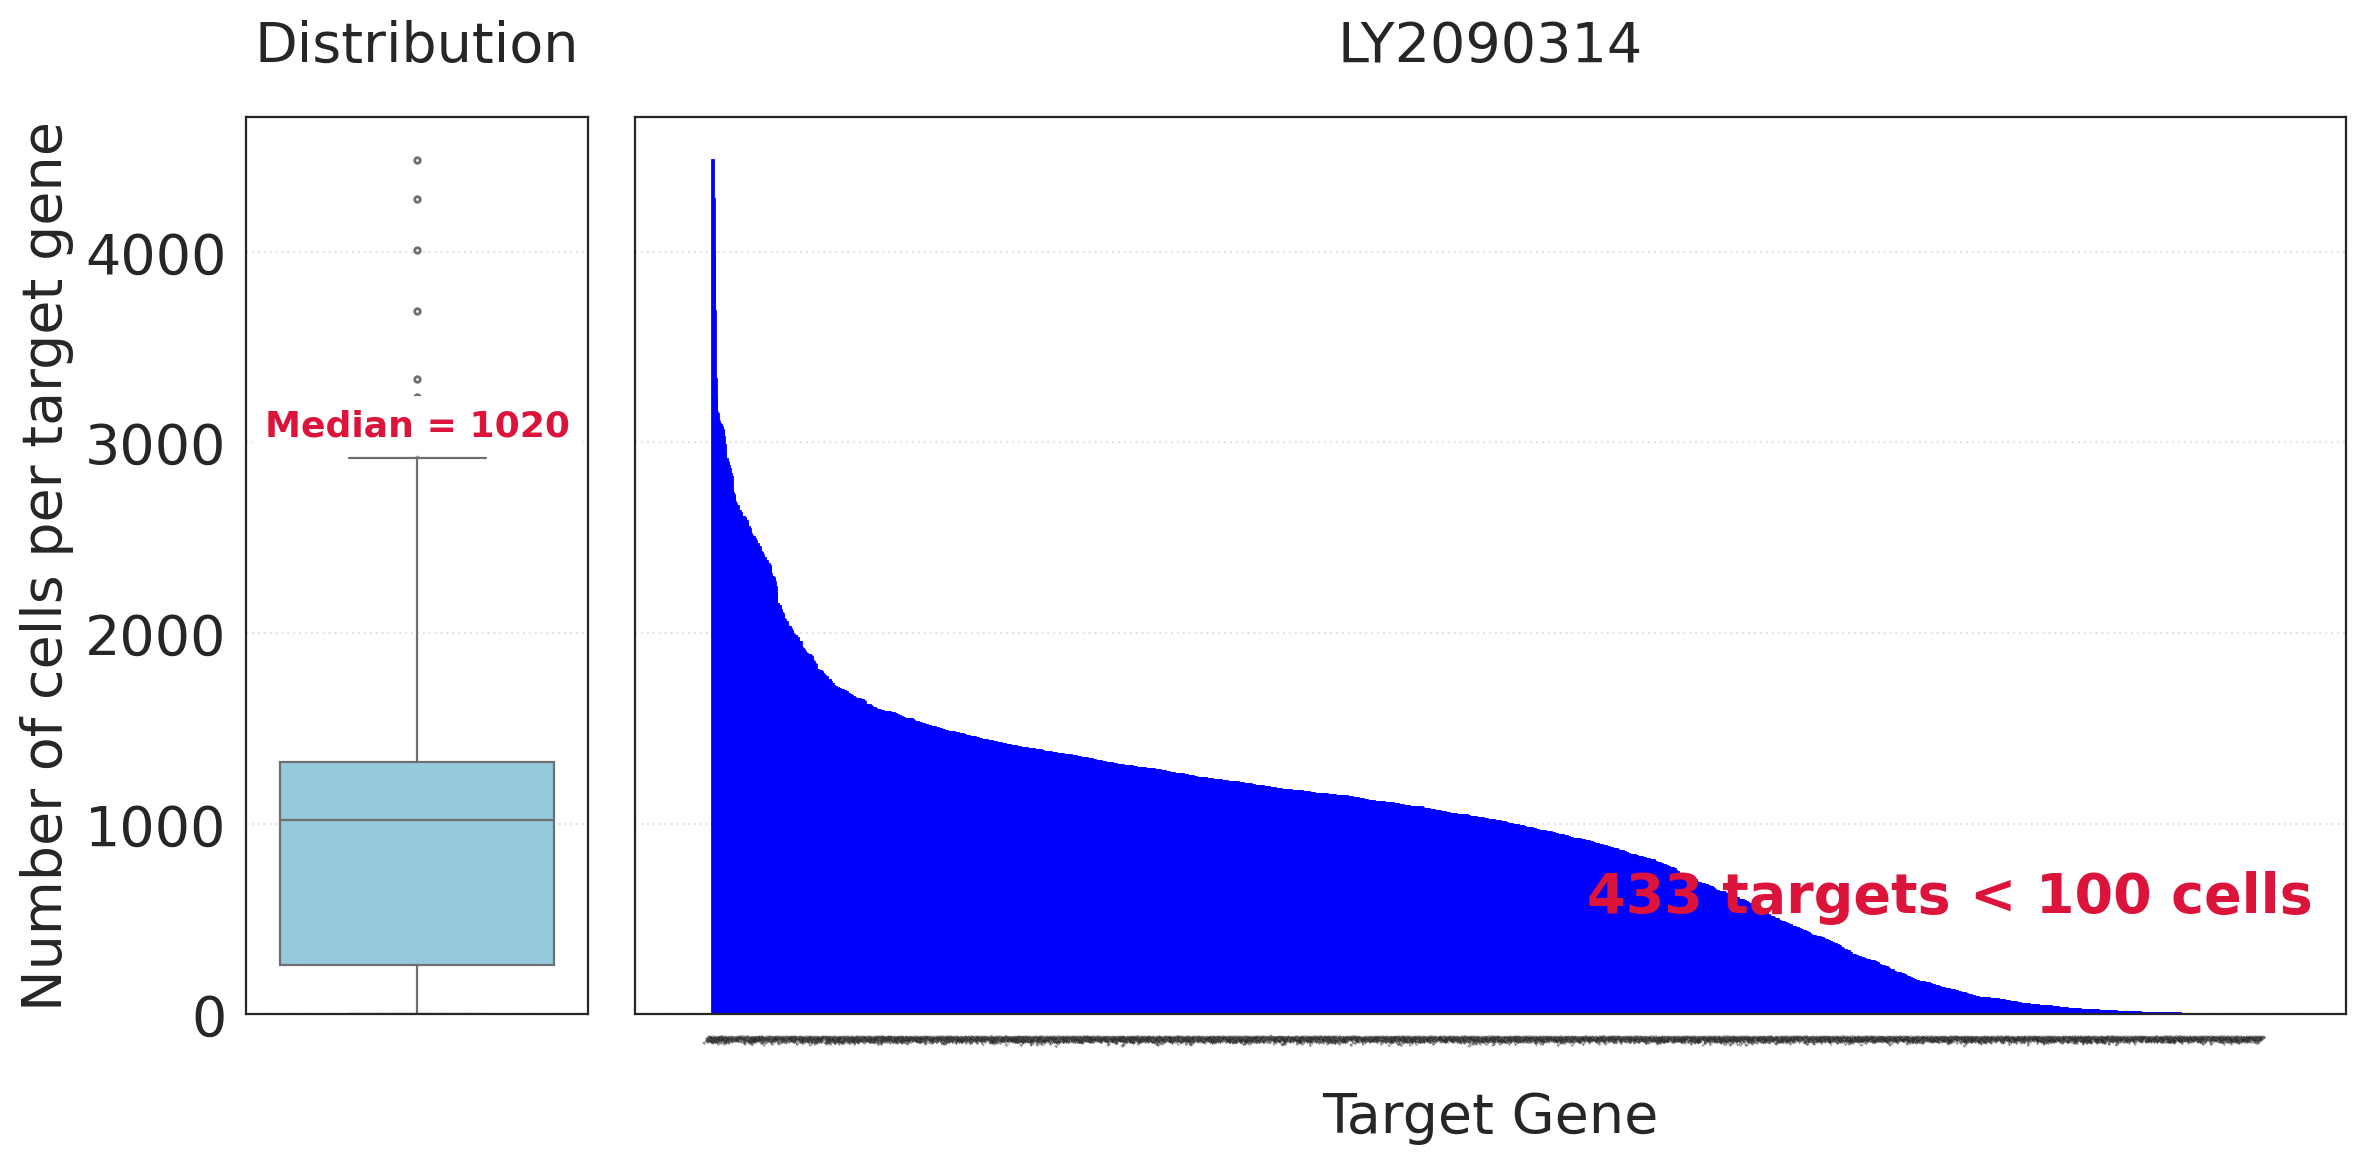

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


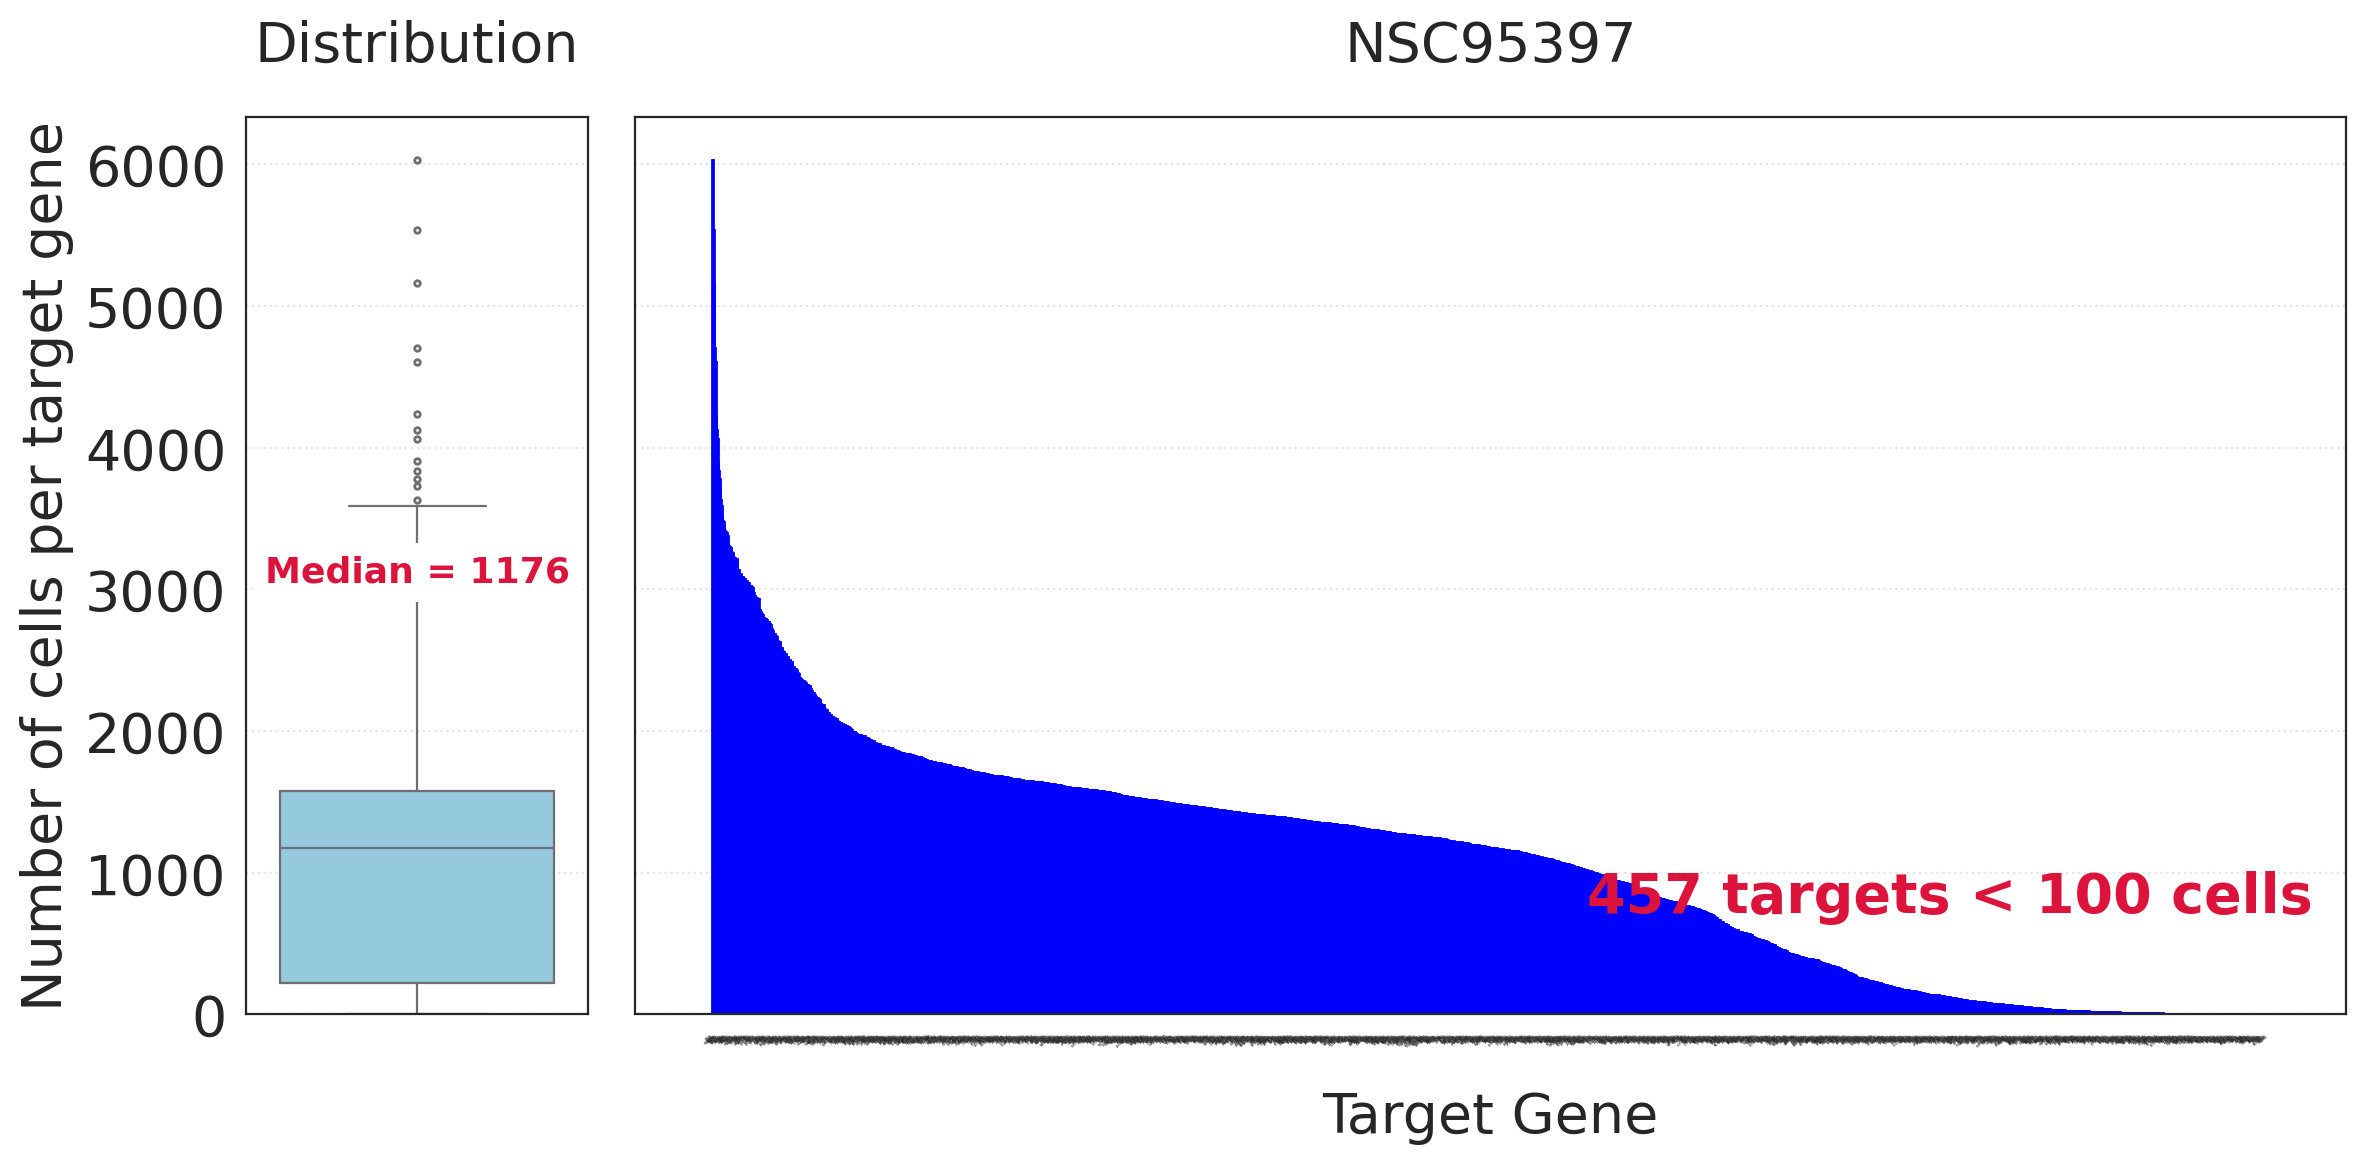

/tmp/ipykernel_1813917/3344251779.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)


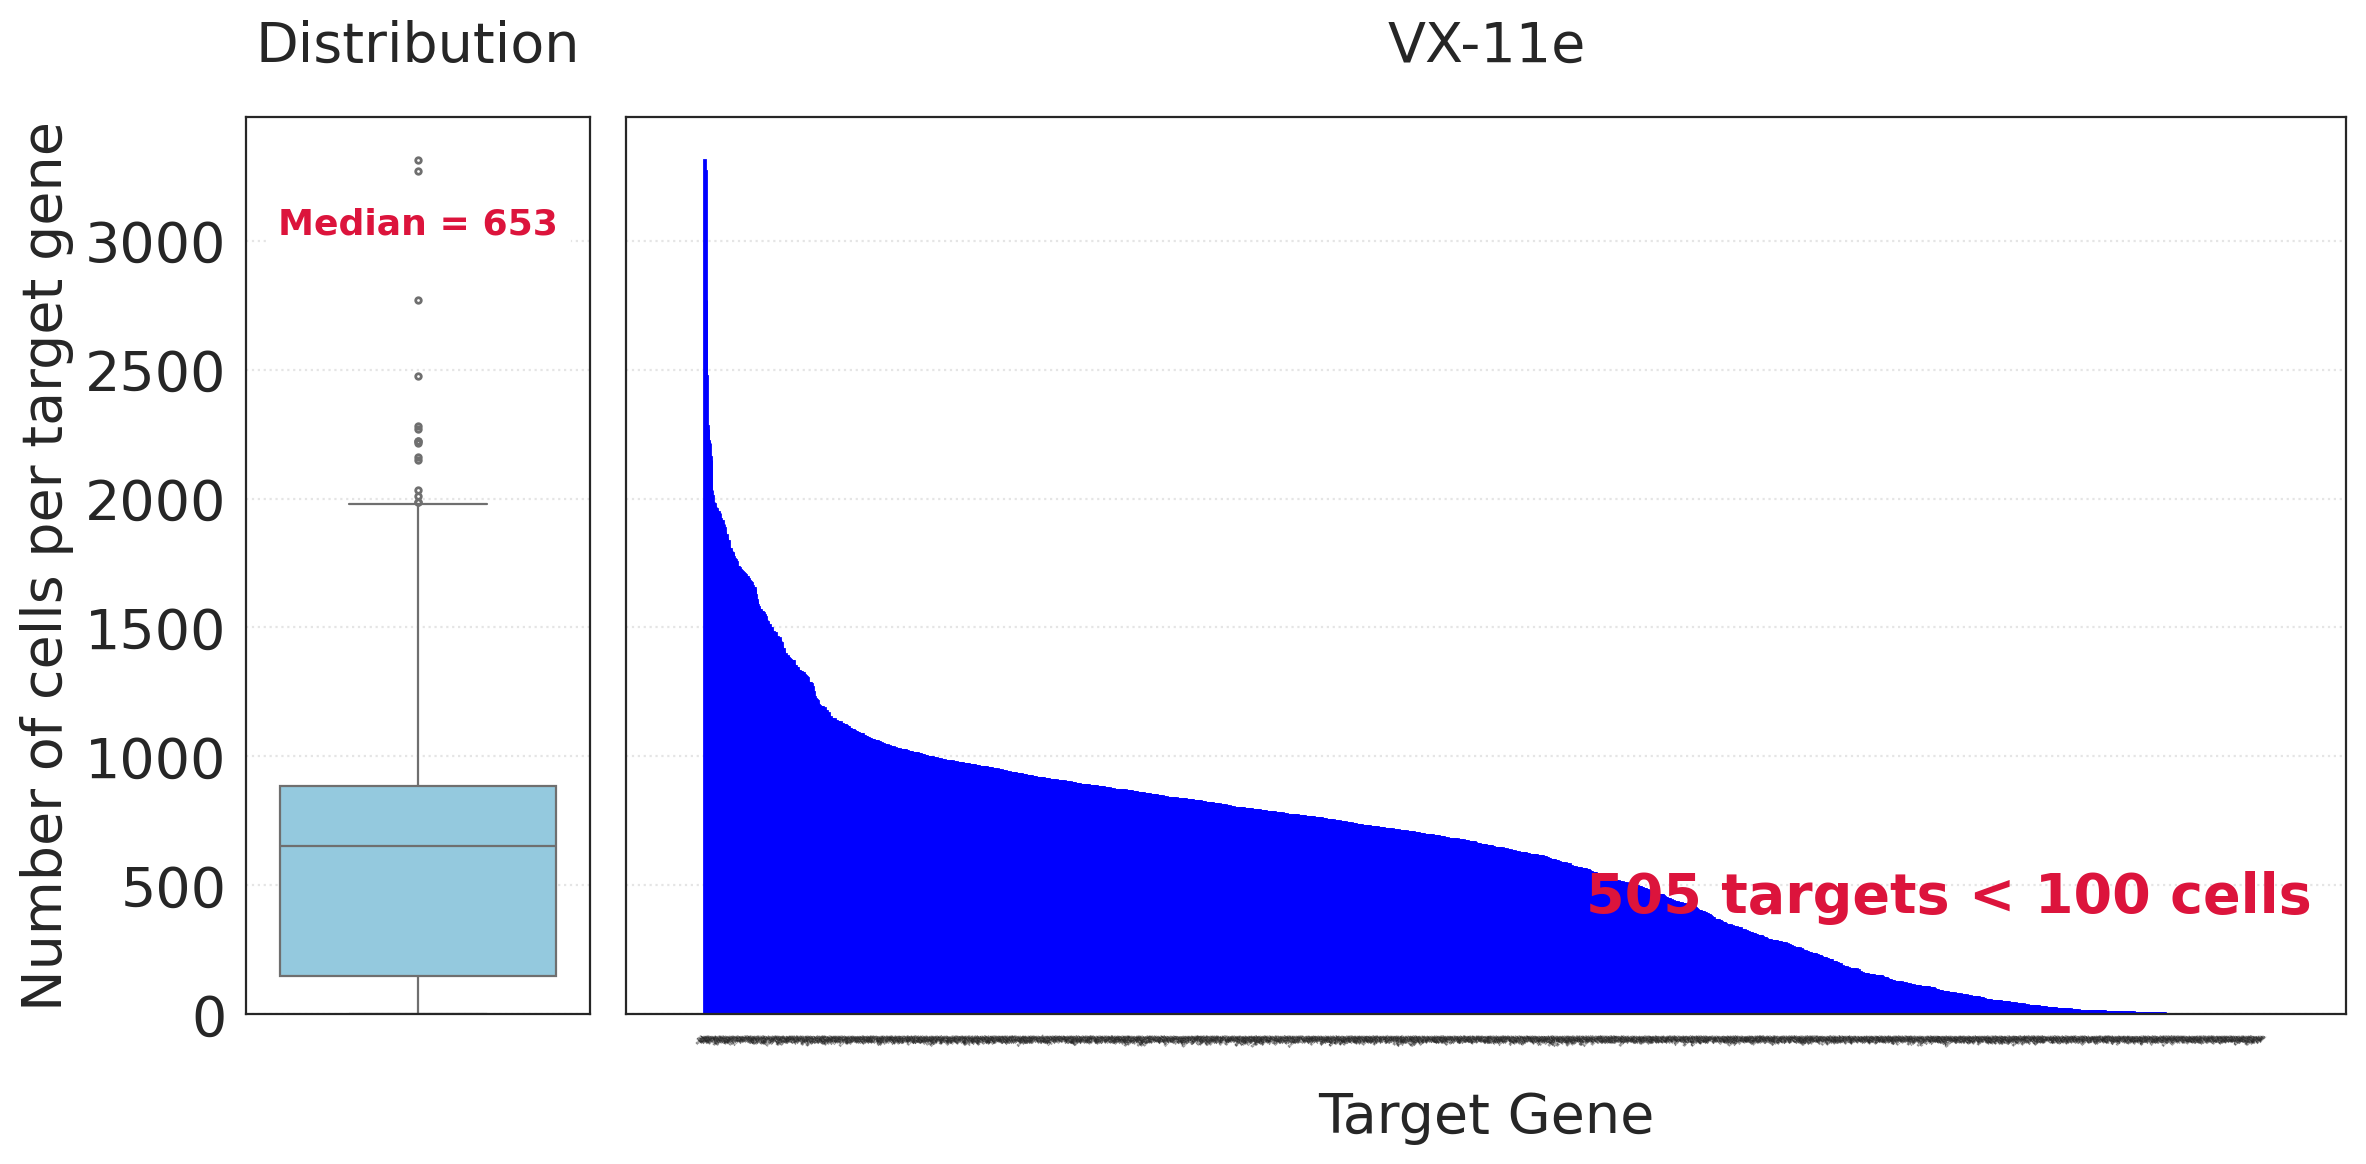

In [4]:
sns.set_style("whitegrid", {"axes.facecolor": "white"})  
sns.set_style("white")
for cond in drugConditions_round2+drugConditions_round2_batch2:
    av = pd.read_csv("./../../DATA/"+cond+"/"+cond+"_KDEfficiency.csv")
    
    # Count cells per target gene, exclude 'non-targeting'
    counts = (
        av.loc[av["target_gene"] != "non-targeting", "target_gene"]
        .value_counts()
    )

    if counts.empty:
        print(f"⚠️  No valid target genes for condition: {cond}")
        continue

    df = counts.reset_index()
    df.columns = ["target_gene", "n_cells"]

    # How many targets have < 100 cells
    few_cells = int((df["n_cells"] < 100).sum())
    median_val = df["n_cells"].median()

    # Side-by-side: left = boxplot (summary), right = per-gene barplot
    fig, (ax_box, ax_bar) = plt.subplots(
        1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [1, 5]}, sharey=True
    )

    # --- LEFT: single box summarizing distribution across genes ---
    sns.boxplot(
        y=df["n_cells"],
        ax=ax_box,
        color="skyblue",
        fliersize=2,
        linewidth=0.8,
        orient="v"
    )
    ax_box.set_xlabel(None)
    ax_box.set_ylabel("Number of cells per target gene", fontsize=20)
    ax_box.tick_params(labelsize=20)
    ax_box.set_title("Distribution", fontsize=20, pad=20)
    ax_box.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax_box.set_xticks([])

    # Add median annotation
    ax_box.text(
        x=0,  # centered on the single box
        y=3000,
        s=f"Median = {median_val:.0f}",
        color="crimson",
        fontsize=13,
        fontweight="bold",
        ha="center",
        va="bottom",
        backgroundcolor="white"
    )

    # --- RIGHT: per-gene barplot (x = gene, y = counts) ---
    ax_bar.bar(df["target_gene"], df["n_cells"], color="skyblue", edgecolor="blue")
    ax_bar.set_xlabel("Target Gene", fontsize=20, labelpad=15)
    ax_bar.set_ylabel(None)  # shared with left
    ax_bar.set_title(f"{cond}", fontsize=20, pad=20)
    ax_bar.set_xticklabels(df["target_gene"], rotation=45, ha="right", size=1)
    ax_bar.grid(True, axis="y", linestyle=":", alpha=0.5)

    # Annotation for low-count targets
    ax_bar.text(
        0.98, 0.10,
        f"{few_cells} targets < 100 cells",
        transform=ax_bar.transAxes,
        ha="right", va="bottom",
        fontsize=20, color="crimson", fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


In [ ]:
adatas = []
for f in drugConditions+drugConditions_round2:
    a = sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1_Basak/"+f+"/"+f+"_control.h5ad")
    a.obs['batch'] = f  # or extract condition name
    adatas.append(a)

adata_all = sc.concat(adatas, join="outer", label="batch")


In [ ]:
adata_all.write("/processed_datasets/VCI/ChemoGenetic_H1_Basak/All_control.h5ad")

In [ ]:
adata_all=sc.read_h5ad("/processed_datasets/VCI/ChemoGenetic_H1_Basak/All_control.h5ad")

In [ ]:
adata_all=sample_adata(adata_all, frac=0.2, random_state=0)

In [ ]:
X = adata_all.X

# Convert to dense safely for inspection
if sp.issparse(X):
    X_dense = X.toarray()
else:
    X_dense = np.asarray(X)

gene_mask = ~np.isnan(X_dense).any(axis=0)
adata_all = adata_all[:, gene_mask].copy()


In [ ]:
adata_all

In [ ]:
sc.pp.scale(adata_all, max_value=10)
sc.pp.pca(adata_all, n_comps=50, svd_solver='arpack')


In [ ]:
sc.pp.neighbors(adata_all, 
            n_neighbors=5,
            metric=par_downstream_neighbor_metric,
            n_pcs=50)
sc.tl.umap(adata_all)


In [ ]:
adata_all

In [ ]:
sc.pl.umap(adata_all, color='sample', 
       #legend_loc='on data', 
       legend_fontoutline=3, 
       legend_fontsize=14, 
       legend_fontweight='normal', 
       title='Drug conditions', 
       #legend_loc="on data",
       vmax=12000,
       show=False, 
       size=0.3);

In [ ]:
gene_list_url = 'https://raw.githubusercontent.com/theislab/scanpy_usage/master/180209_cell_cycle/data/regev_lab_cell_cycle_genes.txt'

cell_cycle_genes = [x.strip().decode('utf-8').upper() for x in urlopen(gene_list_url)]


s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]


sc.tl.score_genes_cell_cycle(adata_all, s_genes=s_genes, g2m_genes=g2m_genes)


In [ ]:
sc.pl.umap(adata_all, color='phase', 
       #legend_loc='on data', 
       legend_fontoutline=3, 
       legend_fontsize=14, 
       legend_fontweight='normal', 
       title='phase', 
       #legend_loc="on data",
       vmax=12000,
       show=False, 
       size=0.3);

In [ ]:
sc.pl.umap(adata_all, color='sample', 
       #legend_loc='on data', 
       legend_fontoutline=3, 
       legend_fontsize=14, 
       legend_fontweight='normal', 
       title='Drug conditions', 
       #legend_loc="on data",
       vmax=12000,
       show=False, 
       size=0.3);

In [ ]:


sc.pl.umap(adata_all, color='experiment', 
       #legend_loc='on data', 
       legend_fontoutline=3, 
       legend_fontsize=14, 
       legend_fontweight='normal', 
       title='experiment', 
       #legend_loc="on data",
       vmax=12000,
       show=False, 
       size=0.3);

In [ ]:
sc.tl.paga(adata_all, groups="sample")


In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

sc.pl.paga(adata_all, color="sample", ax=ax,node_size_scale=15,
    edge_width_scale=1.5,show=False)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
from sklearn.metrics import pairwise_distances

def energy_distance_multivariate(X, Y, metric: str = "euclidean") -> float:
    """
    Multivariate energy distance between two samples X and Y.

    X: (n_x, d), Y: (n_y, d)
    Each row is a d-dimensional observation (here: a cell's gene vector).
    """
    X = np.asarray(X)
    Y = np.asarray(Y)

    D_xy = pairwise_distances(X, Y, metric=metric)
    D_xx = pairwise_distances(X, X, metric=metric)
    D_yy = pairwise_distances(Y, Y, metric=metric)

    return 2.0 * D_xy.mean() - D_xx.mean() - D_yy.mean()

def compute_sample_distance_matrices_multivariate(
    adata,
    sample_key: str = "sample",
    layer: str | None = None,
    out_prefix: str = "sample_distances",
    max_cells_per_sample: int | None = None,
    random_state: int = 0,
    metric: str = "euclidean",
):
    """
    Compute pairwise cosine and multivariate energy distances between samples.

    - Cosine distances are computed between sample mean expression vectors.
    - Energy distances are computed between the full *cell-level distributions*,
      treating each cell as a d-dimensional vector of gene expression.

    Parameters
    ----------
    adata : anndata.AnnData
        AnnData with cells as observations and genes as variables.
    sample_key : str
        Column in `adata.obs` giving the sample ID for each cell.
    layer : str or None
        If not None, use `adata.layers[layer]` instead of `adata.X`.
    out_prefix : str
        Prefix for output CSVs:
          - f"{out_prefix}_cosine.csv"
          - f"{out_prefix}_energy.csv"
    max_cells_per_sample : int or None
        Optional cap on number of cells per sample for energy distance
        (subsampling without replacement for speed).
    random_state : int
        RNG seed for reproducibility of subsampling.
    metric : str
        Distance metric for multivariate energy distance (default "euclidean").

    Returns
    -------
    cos_df : pd.DataFrame
        Sample × sample cosine distance matrix (centroids).
    ed_df : pd.DataFrame
        Sample × sample multivariate energy distance matrix.
    """
    rng = np.random.default_rng(random_state)

    # -------- 1. choose matrix ----------
    X = adata.layers[layer] if layer is not None else adata.X

    # -------- 2. sample labels ----------
    if sample_key not in adata.obs:
        raise KeyError(f"{sample_key!r} not found in adata.obs")
    samples = adata.obs[sample_key].astype("string")
    unique_samples = np.array(sorted(samples.unique()))

    # -------- 3. collect per-sample matrices & centroids ----------
    sample_mats = {}
    sample_means = []

    for s in unique_samples:
        mask = (samples == s).values
        idx = np.where(mask)[0]
        if idx.size == 0:
            raise ValueError(f"No cells found for sample {s!r}.")

        # Optional subsampling for energy distance
        if max_cells_per_sample is not None and idx.size > max_cells_per_sample:
            idx = rng.choice(idx, size=max_cells_per_sample, replace=False)

        X_sub = X[idx]

        # to dense
        if sp.issparse(X_sub):
            X_sub = X_sub.toarray()
        else:
            X_sub = np.asarray(X_sub)

        sample_mats[s] = X_sub

        # centroid for cosine distance (use *all* cells of that sample)
        mask_all = (samples == s).values
        X_all = X[mask_all]
        if sp.issparse(X_all):
            mean_vec = np.asarray(X_all.mean(axis=0)).ravel()
        else:
            mean_vec = np.asarray(X_all).mean(axis=0)
        sample_means.append(mean_vec)

    sample_means = np.vstack(sample_means)  # (n_samples, n_genes)

    # -------- 4. cosine distance between sample centroids ----------
    cos_mat = cosine_distances(sample_means, sample_means)
    cos_df = pd.DataFrame(cos_mat, index=unique_samples, columns=unique_samples)

    # -------- 5. multivariate energy distance between cell distributions ----------
    n = len(unique_samples)
    ed_mat = np.zeros((n, n), dtype=float)

    for i in range(n):
        s_i = unique_samples[i]
        Xi = sample_mats[s_i]
        for j in range(i, n):
            s_j = unique_samples[j]
            Xj = sample_mats[s_j]

            ed = energy_distance_multivariate(Xi, Xj, metric=metric)
            ed_mat[i, j] = ed
            ed_mat[j, i] = ed

    ed_df = pd.DataFrame(ed_mat, index=unique_samples, columns=unique_samples)

    # -------- 6. save ----------
    cos_path = f"{out_prefix}_cosine.csv"
    ed_path  = f"{out_prefix}_energy.csv"

    cos_df.to_csv(cos_path)
    ed_df.to_csv(ed_path)

    print(f"Saved cosine distance matrix to: {cos_path}")
    print(f"Saved energy distance matrix to: {ed_path}")

    return cos_df, ed_df


In [ ]:
compute_sample_distance_matrices_multivariate(
    adata_all,
    sample_key = "sample",  
    out_prefix = "sample_distances",
    max_cells_per_sample= 10000,
    random_state= 0,
    metric = "euclidean",
)

In [ ]:

conditions = [
    "AR-A014418", "AZD4573", "CHIR", "CHIR-98014", "DMSO",
    "DMSO_round2", "KYA", "Lexibulin", "LDN", "PFI1", "PP121",
    "RGFP", "Romidepsin", "Stattic"
]

allRes_FC = []
allRes_FC_null = []

# ---------------------------
# Helper function to process FC/FDR matrices
# ---------------------------
def process_file(elem, suffix=""):
    # Read data
    FCs = pd.read_csv(os.path.join("TextFiles", f"{elem}{suffix}_FCs.csv"), index_col=0)
    FDRs = pd.read_csv(os.path.join("TextFiles", f"{elem}{suffix}_FDRs.csv"), index_col=0)

    # Replace NA values
    FCs = FCs.fillna(0)
    FDRs = FDRs.fillna(1)

    # Mask non-significant genes
    FCs = FCs.mask(FDRs >= 0.1, other=0)

    # Count genes per perturbation (per row)
    nUp = (FCs > 0).sum(axis=1)
    nDown = (FCs < 0).sum(axis=1)

    # Construct a dataframe like in R
    return pd.DataFrame({
        "PerturbationName": FCs.index,
        "N_upRegGenes": nUp.values,
        "N_downRegGenes": nDown.values,
        "N_totalRegGenes": (nUp + nDown).values,
        "Condition": elem
    })


# -------------------------------------
# Process real FCs
# -------------------------------------
for elem in conditions:
    print(elem)
    tmp = process_file(elem)
    allRes_FC.append(tmp)

# -------------------------------------
# Process null FCs
# -------------------------------------
for elem in conditions:
    tmp = process_file(elem, suffix="_null")
    allRes_FC_null.append(tmp)


# -------------------------------------
# Combine results
# -------------------------------------
allRes_FC = pd.concat(allRes_FC, ignore_index=True)
allRes_FC_null = pd.concat(allRes_FC_null, ignore_index=True)

allRes_FC["type"] = "KnockDown"
allRes_FC_null["type"] = "Background"

allRes_FC_all = pd.concat([allRes_FC, allRes_FC_null], ignore_index=True)

# Save if needed:
allRes_FC_all.to_csv("all_FC_results.csv", index=False)


In [ ]:
allRes_FC_all

In [ ]:
allRes_FC_all=pd.read_csv("all_FC_results.csv")

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

def add_empirical_pvals(allRes_FC_all: pd.DataFrame) -> pd.DataFrame:
    df = allRes_FC_all.copy()

    # Columns we'll add
    df["pval_totalRegGenes"] = np.nan
    df["fdr_totalRegGenes"] = np.nan

    # Loop over conditions
    for cond, df_cond in df.groupby("Condition"):
        # Null = Background rows for this condition
        null_mask = (df["Condition"] == cond) & (df["type"] == "Background")
        obs_mask  = (df["Condition"] == cond) & (df["type"] == "KnockDown")

        null_vals = df.loc[null_mask, "N_totalRegGenes"].to_numpy()
        obs_vals  = df.loc[obs_mask, "N_totalRegGenes"].to_numpy()

        if null_vals.size == 0 or obs_vals.size == 0:
            # Nothing to do for this condition
            continue

        # Empirical, right-tailed p-value: P(null >= observed)
        pvals = []
        for v in obs_vals:
            ge = (null_vals >= v).sum()
            p = (ge + 1.0) / (null_vals.size + 1.0)
            pvals.append(p)
        pvals = np.asarray(pvals)

        # Assign back into df
        df.loc[obs_mask, "pval_totalRegGenes"] = pvals

    # Now do BH-FDR globally across all KnockDown rows
    kd_mask = (df["type"] == "KnockDown") & df["pval_totalRegGenes"].notna()
    if kd_mask.sum() > 0:
        rej, qvals, _, _ = multipletests(
            df.loc[kd_mask, "pval_totalRegGenes"].values,
            method="fdr_bh"
        )
        df.loc[kd_mask, "fdr_totalRegGenes"] = qvals

    return df

# Usage:
allRes_FC_all_with_p = add_empirical_pvals(allRes_FC_all)

# Optionally save:


In [ ]:
import pandas as pd
import os

allCond = drugConditions + drugConditions_round2

def build_all_results(allCond):
    allRes = []

    for elem in allCond:
        path = f"{elem}/{elem}_KDEfficiency.csv"
        print("Reading:", path)

        # Read CSV
        a = pd.read_csv(path, index_col=0)

        # Compute median KnockDownEfficiency *ignoring NA*
        a["Mean_KOEf"] = (
            a.groupby("target_gene")["KnockDownEfficiency"]
             .transform(lambda x: x.dropna().median())
        )

        # Count ALL cells per target gene (including NA rows)
        a["N_cells"] = a.groupby("target_gene")["target_gene"].transform("count")

        # Extract unique combinations
        a_unique = a[["sample", "target_gene", "Mean_KOEf", "N_cells"]].drop_duplicates()

        allRes.append(a_unique)

    # Combine all conditions
    allRes_df = pd.concat(allRes, ignore_index=True)
    return allRes_df

allResKD = build_all_results(allCond)


In [ ]:
allResKD.columns = ["Condition","PerturbationName","Mean_KOEf","N_cells"]

In [ ]:
allResKD.Condition.value_counts()

In [ ]:
allRes_FC_all_with_p=allRes_FC_all_with_p.merge(
    allResKD,
    on=["Condition","PerturbationName"],
    how="outer"
)

In [ ]:
allRes_FC_all_with_p

In [ ]:
allRes_FC_all_with_p.to_csv("allRes_FC_all_with_empirical_pvals.csv", index=False)


In [ ]:
allRes_FC_all_with_p.Condition.value_counts()